### Import Data

In [3]:
import polars as pl
from great_tables import GT
import math
import json
import urllib.request, io

# Convert clock strings ("MM:SS" / "M:SS") to total seconds.
# events.Clock uses zero-padded minutes ("09:30"); tracking "Game Clock" is unpadded ("9:30").
# Casting both to integer seconds makes them directly comparable for joins.
def clock_to_seconds(col):
    parts = pl.col(col).str.split(":")
    return (
        parts.list.get(0).cast(pl.Int64) * 60
        + parts.list.get(1).cast(pl.Int64)
    )

# Add the seconds column and slot it right after its source column.
def add_seconds_after(df, src, new):
    df = df.with_columns(clock_to_seconds(src).alias(new))
    cols = [c for c in df.columns if c != new]
    cols.insert(df.get_column_index(src) + 1, new)
    return df.select(cols)

# Every game is read directly from the Big Data Cup 2026 release (no local download).
# Each row is tagged with a "Game" id (the filename stem, e.g. "2025-10-11.Team.A.@.Team.D"),
# identical for a game's Events and Tracking files. That key is required downstream: the
# shots<->tracking joins match on Period + Frame, but Frame is only a per-game counter, so
# without "Game" they would cross-match rows between different games.
_RELEASE_API = "https://api.github.com/repos/bigdatacup/Big-Data-Cup-2026/releases/tags/Data"
_assets = {a["name"]: a["browser_download_url"]
           for a in json.load(urllib.request.urlopen(_RELEASE_API))["assets"]}

def _read_url(url, **kwargs):
    return pl.read_csv(io.BytesIO(urllib.request.urlopen(url).read()), **kwargs)

# Events: one file per game.
event_frames = []
for name, url in _assets.items():
    if not name.endswith(".Events.csv"):
        continue
    game = name[: -len(".Events.csv")]
    df = _read_url(url, schema_overrides={"Player_Id": pl.String, "Player_Id_2": pl.String})
    df = add_seconds_after(df, "Clock", "Clock_Seconds")
    df = df.with_columns(pl.lit(game).alias("Game"))
    event_frames.append(df)
events = pl.concat(event_frames)

# Tracking: P1/P2/P3 (+ POT overtime). ".Tracking_P" excludes Shifts and camera_orientations.
track_frames = []
for name, url in _assets.items():
    if ".Tracking_P" not in name:
        continue
    game = name.split(".Tracking_")[0]
    df = _read_url(url, schema_overrides={"Rink Location Z (Feet)": pl.Float64, "Period": pl.String}).drop("Player Id")
    # Overtime tracking labels Period as "OT"; events use 4 for OT. Normalize to 4 (Int64)
    # so the dtype is consistent across files and OT shots can join their tracking frames.
    df = df.with_columns(pl.col("Period").replace("OT", "4").cast(pl.Int64))
    df = add_seconds_after(df, "Game Clock", "Game_Clock_Seconds")
    df = df.with_columns(pl.lit(game).alias("Game"))
    track_frames.append(df)

# One table of every tracked player-frame across all games and periods.
tracking = pl.concat(track_frames)

### Distribution of Shot Types in the dataset

In [12]:
shot_types = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .group_by("Detail_1")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("pct"))
    .sort("count", descending=True)
)

(
    GT(shot_types)
    .tab_header(title="Distribution of shot types in the dataset")
    .cols_label(Detail_1="Shot Type", pct="% of Shots")
    .fmt_percent("pct", decimals=1)
    .cols_hide("count")
    .cols_width({"Detail_1": "150px", "pct": "110px"})
)


GT(_tbl_data=shape: (8, 3)
┌─────────────┬───────┬──────────┐
│ Detail_1    ┆ count ┆ pct      │
│ ---         ┆ ---   ┆ ---      │
│ str         ┆ u32   ┆ f64      │
╞═════════════╪═══════╪══════════╡
│ Wristshot   ┆ 517   ┆ 0.434454 │
│ Snapshot    ┆ 450   ┆ 0.378151 │
│ Slapshot    ┆ 116   ┆ 0.097479 │
│ Deflection  ┆ 64    ┆ 0.053782 │
│ Fan         ┆ 32    ┆ 0.026891 │
│ Wrap Around ┆ 6     ┆ 0.005042 │
│ Bat         ┆ 3     ┆ 0.002521 │
│ Poke        ┆ 2     ┆ 0.001681 │
└─────────────┴───────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x3c2a3f850>, _boxhead=Boxhead([ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='150px'), ColInfo(var='count', type=<ColInfoTypeEnum.hidden: 4>, column_label='count', column_align='right', column_width=None), ColInfo(var='pct', type=<ColInfoTypeEnum.default: 1>, column_label='% of Shots', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x4b145c050>, _spanners=Spanners([]), _heading=Heading(title='Distribution of shot types in the dataset', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4b14506b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4b14507c0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4b145c2b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4b145c640>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInf

#### Plot

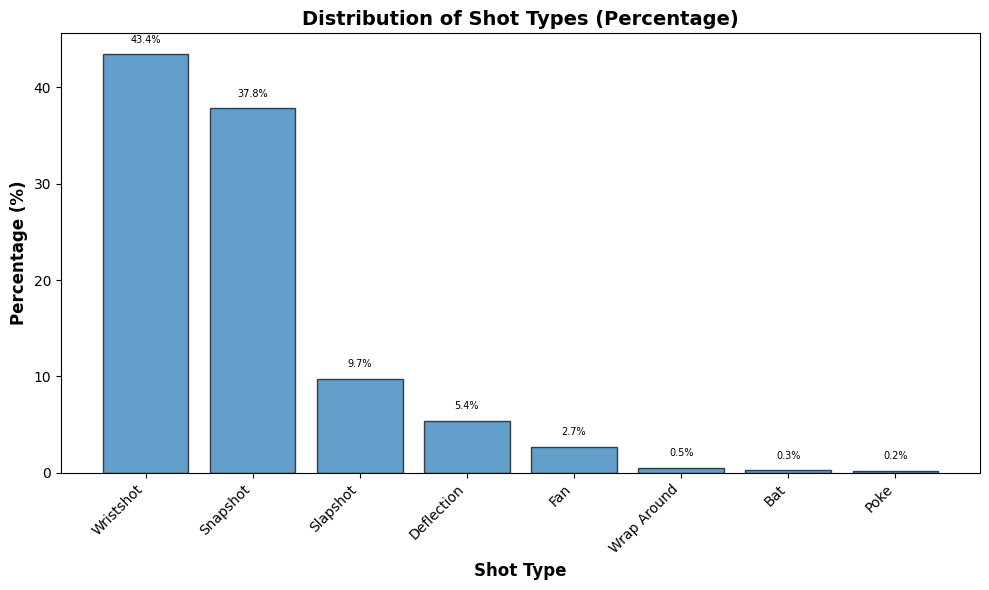

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with percentages
ax.bar(shot_types["Detail_1"], shot_types["pct"] * 100, color="#1f77b4", edgecolor="black", alpha=0.7)

# Customize the plot
ax.set_xlabel("Shot Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Shot Types (Percentage)", fontsize=14, fontweight="bold")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Add percentage labels on top of bars
for i, v in enumerate(shot_types["pct"]):
    ax.text(i, v * 100 + 1, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

### Distribution of Shot Outcomes in the dataset

In [14]:
descriptions = {
    "Saved": "The shot is on target and saved by the goaltender.",
    "Goal": "The shot is on target and not saved by the goaltender, resulting in a goal.",
    "Blocked": "The shot is blocked by a skater from the defending team.",
    "Missed": "The shot is not on target.",
}

shot_outcomes = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .with_columns(
        pl.when(pl.col("Event") == "Goal")
        .then(pl.lit("Goal"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "On Net"))
        .then(pl.lit("Saved"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Blocked"))
        .then(pl.lit("Blocked"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Missed"))
        .then(pl.lit("Missed"))
        .alias("Outcome")
    )
    .group_by("Outcome")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("pct"))
    .with_columns(pl.col("Outcome").replace(descriptions).alias("Description"))
    .select("Outcome", "Description", "pct")
    .sort("pct", descending=True)
)

(
    GT(shot_outcomes)
    .tab_header(title="Distribution of shot outcomes in the dataset")
    .cols_label(
        Outcome="Shot Outcome",
        Description="Description",
        pct="% of Shots",
    )
    .fmt_percent("pct", decimals=1)
    .cols_width({"Outcome": "130px", "Description": "420px", "pct": "110px"})
)


GT(_tbl_data=shape: (4, 3)
┌─────────┬─────────────────────────────────┬──────────┐
│ Outcome ┆ Description                     ┆ pct      │
│ ---     ┆ ---                             ┆ ---      │
│ str     ┆ str                             ┆ f64      │
╞═════════╪═════════════════════════════════╪══════════╡
│ Saved   ┆ The shot is on target and save… ┆ 0.426891 │
│ Missed  ┆ The shot is not on target.      ┆ 0.280672 │
│ Blocked ┆ The shot is blocked by a skate… ┆ 0.243697 │
│ Goal    ┆ The shot is on target and not … ┆ 0.048739 │
└─────────┴─────────────────────────────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x4b14d8bb0>, _boxhead=Boxhead([ColInfo(var='Outcome', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Outcome', column_align='left', column_width='130px'), ColInfo(var='Description', type=<ColInfoTypeEnum.default: 1>, column_label='Description', column_align='left', column_width='420px'), ColInfo(var='pct', type=<ColInfoTypeEnum.default: 1>, column_label='% of Shots', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x4b145ce90>, _spanners=Spanners([]), _heading=Heading(title='Distribution of shot outcomes in the dataset', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3c2a3ec50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3c2a3e650>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4b145d350>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4b145d480>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=Options

### Feature-Based Expected Goals Model

#### Visualize Shot Location

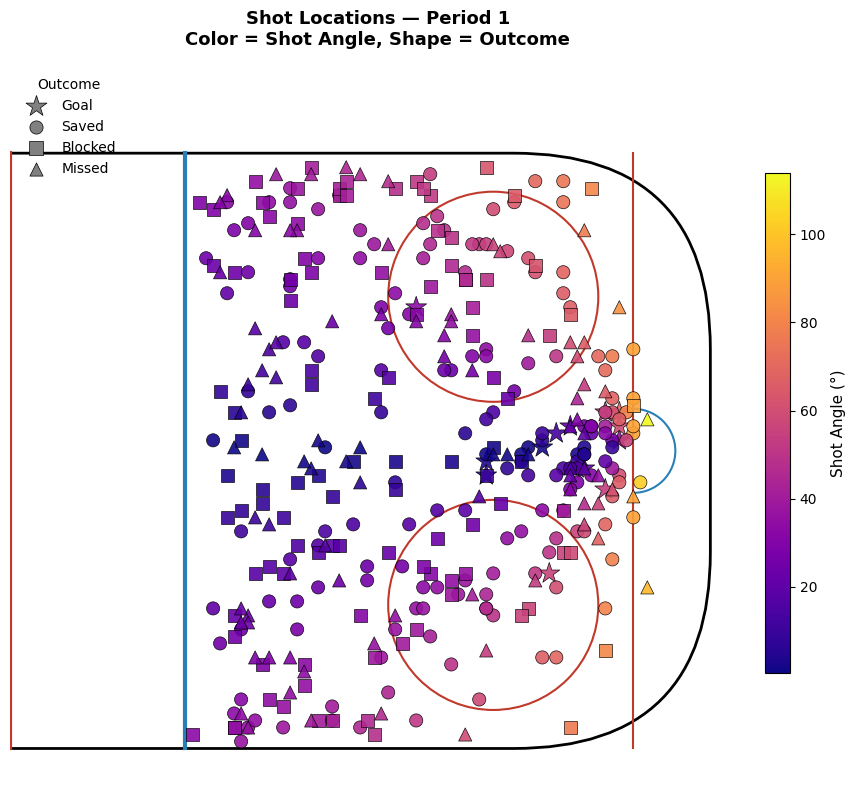

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Arc, Circle, FancyBboxPatch

# Prepare shot data with outcome labels, normalized coordinates, and shot angle
shot_data = (
    events
    .filter(
        pl.col("Event").is_in(["Shot", "Goal"]),
        pl.col("Period") == 1,
    )
    .with_columns(
        pl.when(pl.col("Event") == "Goal")
        .then(pl.lit("Goal"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "On Net"))
        .then(pl.lit("Saved"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Blocked"))
        .then(pl.lit("Blocked"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Missed"))
        .then(pl.lit("Missed"))
        .alias("Outcome")
    )
    # Normalize all shots to the right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Compute shot angle: 0° = straight on, 90° = side of net
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / 3.141592653589793)
        ).alias("Shot_Angle")
    )
    .select("X_Coordinate", "Y_Coordinate", "Outcome", "Shot_Angle")
)

outcome_markers = {
    "Goal":    {"marker": "*", "size": 250},
    "Saved":   {"marker": "o", "size":  90},
    "Blocked": {"marker": "s", "size":  90},
    "Missed":  {"marker": "^", "size":  90},
}

cmap = plt.cm.plasma
angles = shot_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#e8f4fb")

# --- Rink ---
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))
for x, color, lw in [(0, "#c0392b", 3.0), (25, "#2980b9", 3.0), (89, "#c0392b", 1.5)]:
    ax.plot([x, x], [-42.5, 42.5], color=color, linewidth=lw, zorder=2)
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot shots: color = angle, shape = outcome ---
for outcome, style in outcome_markers.items():
    subset = shot_data.filter(pl.col("Outcome") == outcome)
    ax.scatter(
        subset.get_column("X_Coordinate").to_list(),
        subset.get_column("Y_Coordinate").to_list(),
        c=subset.get_column("Shot_Angle").to_list(),
        cmap=cmap, norm=norm,
        marker=style["marker"], s=style["size"],
        zorder=5, edgecolors="black", linewidths=0.5, alpha=0.9,
    )

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Shot Angle (°)", fontsize=11)

# --- Legend for shapes ---
handles = [
    plt.scatter([], [], marker=s["marker"], s=s["size"], c="gray",
                edgecolors="black", linewidths=0.5, label=o)
    for o, s in outcome_markers.items()
]
ax.legend(handles=handles, loc="upper left", fontsize=10, frameon=False, title="Outcome")

ax.set_xlim(0, 105)
ax.set_ylim(-47, 55)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Shot Locations — Period 1\nColor = Shot Angle, Shape = Outcome", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


#### Shot Location

In [16]:
shot_location = (
    events
    .filter(pl.col("Event").is_in(["Shot", "Goal"]))
    # Normalize to right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Shot angle (degrees) and meridian distance
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / math.pi)
        ).alias("Shot_Angle"),
        pl.col("Y_Coordinate").abs().alias("d_m"),
    )
    # Distance via trigonometry: d = d_m / sin(θ), fallback to (89 - x) when Y = 0
    .with_columns(
        pl.when(pl.col("d_m") == 0)
        .then(89 - pl.col("X_Coordinate"))
        .otherwise(
            pl.col("d_m") / (pl.col("Shot_Angle") * math.pi / 180).sin()
        )
        .alias("d_trig"),
        # Euclidean distance as sanity check
        ((89 - pl.col("X_Coordinate")).pow(2) + pl.col("Y_Coordinate").pow(2))
        .sqrt()
        .alias("d_euclidean"),
    )
)



##### Notes
1. `Shot_Angle`: Shot angle (The angle of the shot)
2. `d_m`: Meridian distance (The distance between the shot location and the meridian)
3. `d_trig`/`d_euclidean`: Shot distance (The distance between the shot location and the goal)
    - `d_trig` and `d_euclidean` are equal. `d_euclidean` calculated as a sanity check

#### Shooter Motion

In [17]:
# Goal: the shooter's *speed* (magnitude of velocity) at the instant they shot.
# Tracking gives position over time; events tell us who/when/where each shot was.
#
# Tracking runs at ~30 fps: the "Image Id" suffix is a per-period frame counter that
# ticks ~30 times per game-clock second (e.g. "..._066486" -> "..._066487"). Frames
# occasionally drop, so velocity uses the *actual* frame-index gap for dt, never an
# assumed constant. We smooth with a small central difference to damp tracking jitter.

FPS = 30                  # tracking frame rate (frames per second)
SMOOTH_K = 3              # central-difference half-window (~0.1 s each side)
FT_PER_S_TO_MPH = 0.6818  # 1 ft/s = 0.6818 mph
MAX_SPEED_MPH = 30.0      # human skaters peak ~25 mph; above this is a tracking glitch
MAX_SPEED_FPS = MAX_SPEED_MPH / FT_PER_S_TO_MPH

players = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .with_columns(
        # Numeric frame index from the Image Id suffix, and jersey as a string for matching.
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame"),
        pl.col("Player Jersey Number").cast(pl.String).alias("Jersey"),
    )
    # Drop rows whose jersey couldn't be read: they'd all collapse into one bogus "null"
    # track, and differencing positions of *different* players invents huge fake speeds.
    .filter(pl.col("Jersey").is_not_null())
    # Order each player's frames in time so shift() walks consecutive samples.
    .sort(["Game", "Period", "Team", "Jersey", "Frame"])
    .with_columns(
        # Central difference over +/- SMOOTH_K frames, partitioned per player-period.
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K))
            .over(["Game", "Period", "Team", "Jersey"]).alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K))
            .over(["Game", "Period", "Team", "Jersey"]).alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K))
            .over(["Game", "Period", "Team", "Jersey"]).alias("dframe"),
    )
    .with_columns(
        # dt = frames / fps (seconds); speed = displacement / dt, in feet per second.
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("speed_fps")
    )
    .with_columns(
        # Null out physically impossible speeds (tracking ID-swaps / position jumps) so
        # they don't poison the per-shot pick or its fallback median.
        pl.when(pl.col("speed_fps") <= MAX_SPEED_FPS).then(pl.col("speed_fps")).otherwise(None).alias("speed_fps")
    )
    .with_columns(
        (pl.col("speed_fps") * FT_PER_S_TO_MPH).alias("speed_mph")
    )
)

# Peek at the players table
players.select(
    "Game", "Period", "Team", "Jersey", "Frame", "Game_Clock_Seconds",
    "Rink Location X (Feet)", "Rink Location Y (Feet)", "speed_fps", "speed_mph",
)

Game,Period,Team,Jersey,Frame,Game_Clock_Seconds,Rink Location X (Feet),Rink Location Y (Feet),speed_fps,speed_mph
str,i64,str,str,i64,i64,f64,f64,f64,f64
"""2025-10-11.Team.A.@.Team.D""",1,"""Away""","""14""",71948,1053,67.427,21.172,null,null
"""2025-10-11.Team.A.@.Team.D""",1,"""Away""","""14""",71949,1052,67.304,21.257,null,null
"""2025-10-11.Team.A.@.Team.D""",1,"""Away""","""14""",71950,1052,67.365,21.779,null,null
"""2025-10-11.Team.A.@.Team.D""",1,"""Away""","""14""",71951,1052,67.723,22.361,14.579383,9.940223
"""2025-10-11.Team.A.@.Team.D""",1,"""Away""","""14""",71952,1052,67.885,22.909,17.321562,11.809841
…,…,…,…,…,…,…,…,…,…
"""2025-11-28.Team.J.@.Team.K""",4,"""Home""","""Go""",343566,183,85.025,-2.992,0.21272,0.145033
"""2025-11-28.Team.J.@.Team.K""",4,"""Home""","""Go""",343567,183,85.025,-2.99,0.071589,0.048809
"""2025-11-28.Team.J.@.Team.K""",4,"""Home""","""Go""",343568,183,85.025,-2.99,null,null


In [18]:
# Match each Shot/Goal event to the tracking frame where the puck was released, then
# read the shooter's speed there.
#
# Matching keys: events Player_Id is a jersey number, but jerseys repeat across teams,
# so we match on Period + Team + Jersey. Event "Team" is a name (e.g. "Team A");
# tracking "Team" is Home/Away -> map via Home_Team/Away_Team.
#
# Pinning the release: the event stores the release X/Y. Within +/-1 game-clock second
# of the event we pick the shooter frame whose tracked position is closest to that
# release point. Event and tracking share the same rink frame here, but to be safe we
# also test the sign-flipped coords (-X,-Y) and keep whichever is closer.

shots = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .with_columns(
        pl.when(pl.col("Team") == pl.col("Home_Team")).then(pl.lit("Home"))
          .otherwise(pl.lit("Away")).alias("Track_Team")
    )
    .with_row_index("shot_id")
)

# Candidate shooter frames: same player, within the event second (+/-1s), valid position.
cand = (
    shots.join(
        players.select([
            "Game", "Period", "Team", "Jersey", "Game_Clock_Seconds", "Frame",
            "Rink Location X (Feet)", "Rink Location Y (Feet)", "speed_fps",
        ]),
        left_on=["Game", "Period", "Track_Team", "Player_Id"],
        right_on=["Game", "Period", "Team", "Jersey"], how="left",
    )
    .filter((pl.col("Game_Clock_Seconds") - pl.col("Clock_Seconds")).abs() <= 1)
    .filter(pl.col("Rink Location X (Feet)").is_not_null()
            & pl.col("Rink Location Y (Feet)").is_not_null())
    .with_columns(
        ((pl.col("Rink Location X (Feet)") - pl.col("X_Coordinate")) ** 2
         + (pl.col("Rink Location Y (Feet)") - pl.col("Y_Coordinate")) ** 2).sqrt().alias("d_direct"),
        ((pl.col("Rink Location X (Feet)") + pl.col("X_Coordinate")) ** 2
         + (pl.col("Rink Location Y (Feet)") + pl.col("Y_Coordinate")) ** 2).sqrt().alias("d_flip"),
    )
    .with_columns(
        pl.min_horizontal("d_direct", "d_flip").alias("match_dist"),
        (pl.col("d_flip") < pl.col("d_direct")).alias("used_flip"),
    )
)

# Release frame = the candidate closest to the release point (nulls_last so a real
# match is never beaten by a missing distance).
release = (
    cand.sort("match_dist", nulls_last=True)
    .group_by("shot_id", maintain_order=True)
    .first()
    .select(["shot_id", "Frame", "match_dist", "used_flip", "speed_fps"])
)

# Fallback: representative speed over the whole event-second window.
window_med = cand.group_by("shot_id").agg(
    pl.col("speed_fps").median().alias("speed_fps_window_median"),
    pl.len().alias("n_candidates"),
)

# A match is trusted when the closest frame is within ~10 ft and has a defined speed;
# otherwise fall back to the window median (flagged), or mark no tracking at all.
MAX_MATCH_DIST = 10.0
shot_speeds = (
    shots.join(release, on="shot_id", how="left")
    .join(window_med, on="shot_id", how="left")
    .with_columns(
        pl.when((pl.col("match_dist") <= MAX_MATCH_DIST) & pl.col("speed_fps").is_not_null())
          .then(pl.col("speed_fps"))
          .otherwise(pl.col("speed_fps_window_median"))
          .alias("shooter_speed_fps"),
        pl.when((pl.col("match_dist") <= MAX_MATCH_DIST) & pl.col("speed_fps").is_not_null())
          .then(pl.lit("matched"))
          .when(pl.col("speed_fps_window_median").is_not_null())
          .then(pl.lit("fallback_window_median"))
          .otherwise(pl.lit("no_tracking"))
          .alias("match_quality"),
    )
    .with_columns((pl.col("shooter_speed_fps") * 0.6818).alias("shooter_speed_mph"))
    .sort(["Game", "Period", "Clock_Seconds"], descending=[False, False, True])
)

print(shot_speeds["match_quality"].value_counts())
shot_speeds.select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "Frame", "match_dist", "used_flip", "shooter_speed_fps", "match_quality",
).head()


shape: (3, 2)
┌────────────────────────┬───────┐
│ match_quality          ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ no_tracking            ┆ 171   │
│ fallback_window_median ┆ 61    │
│ matched                ┆ 958   │
└────────────────────────┴───────┘


Period,Clock,Team,Player_Id,Event,Detail_1,Frame,match_dist,used_flip,shooter_speed_fps,match_quality
i64,str,str,str,str,str,i64,f64,bool,f64,str
1,"""19:54""","""Team D""","""42""","""Shot""","""Wristshot""",65668,1.257159,false,22.062466,"""matched"""
1,"""19:26""","""Team A""","""29""","""Shot""","""Wristshot""",66490,3.945989,false,20.065956,"""matched"""
1,"""19:16""","""Team A""","""72""","""Shot""","""Wristshot""",66824,4.759513,false,4.372238,"""matched"""
1,"""19:15""","""Team A""","""29""","""Shot""","""Deflection""",66861,1.051468,false,3.771091,"""matched"""
1,"""19:13""","""Team A""","""63""","""Shot""","""Wristshot""",66873,0.13366,false,4.189063,"""matched"""


In [19]:
# Shooter speed at the moment of each shot, in ft/s and mph.
shot_speed_table = shot_speeds.select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "shooter_speed_fps", "shooter_speed_mph", "match_quality",
)

(
    GT(shot_speed_table)
    .tab_header(
        title="Shooter speed at the moment of the shot",
        subtitle="Magnitude of the shooter's velocity from tracking, pinned to the release frame",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        shooter_speed_fps="Speed (ft/s)",
        shooter_speed_mph="Speed (mph)",
        match_quality="Match",
    )
    .fmt_number(["shooter_speed_fps", "shooter_speed_mph"], decimals=1)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "shooter_speed_fps": "110px", "shooter_speed_mph": "110px", "match_quality": "150px",
    })
)


GT(_tbl_data=shape: (1_190, 9)
┌────────┬───────┬────────┬───────────┬───┬────────────┬──────────────┬──────────────┬─────────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_Id ┆ … ┆ Detail_1   ┆ shooter_spee ┆ shooter_spee ┆ match_quali │
│ ---    ┆ ---   ┆ ---    ┆ ---       ┆   ┆ ---        ┆ d_fps        ┆ d_mph        ┆ ty          │
│ i64    ┆ str   ┆ str    ┆ str       ┆   ┆ str        ┆ ---          ┆ ---          ┆ ---         │
│        ┆       ┆        ┆           ┆   ┆            ┆ f64          ┆ f64          ┆ str         │
╞════════╪═══════╪════════╪═══════════╪═══╪════════════╪══════════════╪══════════════╪═════════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42        ┆ … ┆ Wristshot  ┆ 22.062466    ┆ 15.04219     ┆ matched     │
│ 1      ┆ 19:26 ┆ Team A ┆ 29        ┆ … ┆ Wristshot  ┆ 20.065956    ┆ 13.680969    ┆ matched     │
│ 1      ┆ 19:16 ┆ Team A ┆ 72        ┆ … ┆ Wristshot  ┆ 4.372238     ┆ 2.980992     ┆ matched     │
│ 1      ┆ 19:15 ┆ Team A ┆ 29        ┆ … ┆ Deflection ┆ 3.771091     ┆ 2.57113      ┆ matched     │
│ 1      ┆ 19:13 ┆ Team A ┆ 63        ┆ … ┆ Wristshot  ┆ 4.189063     ┆ 2.856103     ┆ matched     │
│ …      ┆ …     ┆ …      ┆ …         ┆ … ┆ …          ┆ …            ┆ …            ┆ …           │
│ 3      ┆ 00:10 ┆ Team J ┆ 12        ┆ … ┆ Snapshot   ┆ 15.257465    ┆ 10.402539    ┆ matched     │
│ 4      ┆ 03:41 ┆ Team J ┆ 77        ┆ … ┆ Snapshot   ┆ null         ┆ null         ┆ no_tracking │
│ 4      ┆ 03:28 ┆ Team K ┆ 78        ┆ … ┆ Snapshot   ┆ null         ┆ null         ┆ no_tracking │
│ 4      ┆ 03:13 ┆ Team J ┆ 25        ┆ … ┆ Snapshot   ┆ 7.824981     ┆ 5.335072     ┆ matched     │
│ 4      ┆ 03:06 ┆ Team J ┆ 88        ┆ … ┆ Snapshot   ┆ 6.98306      ┆ 4.76105      ┆ matched     │
└────────┴───────┴────────┴───────────┴───┴────────────┴──────────────┴──────────────┴─────────────┘, _body=<great_tables._gt_data.Body object at 0x4b14e3b90>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='90px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='70px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='110px'), ColInfo(var='shooter_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (ft/s)', column_align='right', column_width='110px'), ColInfo(var='shooter_speed_mph', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (mph)', column_align='right', column_width='110px'), ColInfo(var='match_quality', type=<ColInfoTypeEnum.default: 1>, column_label='Match', column_align='left', column_width='150px')]), _stub=<great_tables._gt_data.Stub object at 0x4b1466f90>, _spanners=Spanners([]), _heading=Heading(title='Shooter speed at the moment of the shot', subtitle="Magnitude of the shooter's velocity from tracking, pinned to the release frame", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4b155e5d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4b155e6c0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4b14670b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4b1464830>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scs

##### Notes
1. `shooter_speed_mph`/`shooter_speed_fps`: Shooter's speed in mph/fps (Shooter is defined as player closest to each shot)

#### Pressure

In [20]:
shot_frames = (
    shots
    .join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("Track_Team") == "Home").then(pl.lit("Away"))
          .otherwise(pl.lit("Home")).alias("Def_Team"),
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate"))
          .otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate"))
          .otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
)

shot_frames

shot_id,Date,Home_Team,Away_Team,Period,Clock,Clock_Seconds,Home_Team_Skaters,Away_Team_Skaters,Home_Team_Goals,Away_Team_Goals,Team,Player_Id,Event,X_Coordinate,Y_Coordinate,Detail_1,Detail_2,Detail_3,Detail_4,Player_Id_2,X_Coordinate_2,Y_Coordinate_2,Game,Track_Team,Frame,used_flip,Def_Team,Shot_X,Shot_Y
u32,str,str,str,i64,str,i64,i64,i64,i64,i64,str,str,str,f64,f64,str,str,i64,i64,str,f64,f64,str,str,i64,bool,str,f64,f64
0,"""2025-10-11""","""Team D""","""Team A""",1,"""19:54""",1194,5,5,0,0,"""Team D""","""42""","""Shot""",42.0,-30.5,"""Wristshot""","""Blocked""",1,0,null,null,null,"""2025-10-11.Team.A.@.Team.D""","""Home""",65668,false,"""Away""",42.0,-30.5
1,"""2025-10-11""","""Team D""","""Team A""",1,"""19:26""",1166,5,5,0,0,"""Team A""","""29""","""Shot""",-79.0,8.5,"""Wristshot""","""Blocked""",0,0,null,null,null,"""2025-10-11.Team.A.@.Team.D""","""Away""",66490,false,"""Home""",-79.0,8.5
2,"""2025-10-11""","""Team D""","""Team A""",1,"""19:16""",1156,5,5,0,0,"""Team A""","""72""","""Shot""",-34.0,23.5,"""Wristshot""","""Missed""",1,0,null,null,null,"""2025-10-11.Team.A.@.Team.D""","""Away""",66824,false,"""Home""",-34.0,23.5
3,"""2025-10-11""","""Team D""","""Team A""",1,"""19:15""",1155,5,5,0,0,"""Team A""","""29""","""Shot""",-74.0,3.5,"""Deflection""","""On Net""",1,0,null,null,null,"""2025-10-11.Team.A.@.Team.D""","""Away""",66861,false,"""Home""",-74.0,3.5
4,"""2025-10-11""","""Team D""","""Team A""",1,"""19:13""",1153,5,5,0,0,"""Team A""","""63""","""Shot""",-81.0,0.5,"""Wristshot""","""On Net""",0,0,null,null,null,"""2025-10-11.Team.A.@.Team.D""","""Away""",66873,false,"""Home""",-81.0,0.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1185,"""2025-11-28""","""Team K""","""Team J""",3,"""00:10""",10,5,5,2,2,"""Team J""","""12""","""Shot""",-38.0,15.5,"""Snapshot""","""Missed""",1,0,null,null,null,"""2025-11-28.Team.J.@.Team.K""","""Away""",332081,false,"""Home""",-38.0,15.5
1186,"""2025-11-28""","""Team K""","""Team J""",4,"""03:41""",221,3,3,2,2,"""Team J""","""77""","""Shot""",66.0,-15.5,"""Snapshot""","""On Net""",0,0,null,null,null,"""2025-11-28.Team.J.@.Team.K""","""Away""",null,null,"""Home""",66.0,-15.5
1187,"""2025-11-28""","""Team K""","""Team J""",4,"""03:28""",208,3,3,2,2,"""Team K""","""78""","""Shot""",66.0,-17.5,"""Snapshot""","""Missed""",0,0,null,null,null,"""2025-11-28.Team.J.@.Team.K""","""Home""",null,null,"""Away""",66.0,-17.5


In [21]:
# Pressure: distance from the shot location to the closest and second-closest
# *defending skater*. Following the cited paper, a continuous distance is more
# descriptive than counting defenders within 6 ft, and adding the second-closest
# defender captures pressure from multiple defenders.
#
# Goalies (jersey "Go") are excluded: a goalie sits in the crease on nearly every
# shot, so it would dominate the "closest defender" distance without reflecting
# real defensive pressure.
#
# We reuse the release Frame matched in the shooter-speed step: at that frame we take
# every opposing skater's tracked position and measure straight-line distance to the
# shot location. "used_flip" (from the same matching) tells us whether the event's
# (X, Y) had to be negated to line up with the tracking frame for that shot, so we
# apply the same flip to the shot coordinates here.
#
# Note: tracking coverage is partial -- many frames carry fewer than 5 skaters per team
# (see n_defenders). Coverage concentrates near the play, so the closest defenders (the
# ones this feature needs) are the most reliably tracked; n_defenders records how many
# defenders were actually visible at each shot's release frame.

# Defending skaters only: opposite tracking team, real jersey numbers, no goalies.
defenders = (
    players
    .filter(pl.col("Jersey") != "Go")
    .select([
        "Game", "Period", "Team", "Frame",
        "Rink Location X (Feet)", "Rink Location Y (Feet)",
    ])
)

# Per shot: the defending team, the release frame, and the shot location in tracking
# coordinates (negated when the release match used the flip).
shot_frames = (
    shots
    .join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("Track_Team") == "Home").then(pl.lit("Away"))
          .otherwise(pl.lit("Home")).alias("Def_Team"),
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate"))
          .otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate"))
          .otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .select(["shot_id", "Game", "Period", "Def_Team", "Frame", "Shot_X", "Shot_Y"])
)

# Join each shot to every defending skater in its release frame; measure distance.
pressure = (
    shot_frames
    .join(
        defenders,
        left_on=["Game", "Period", "Def_Team", "Frame"],
        right_on=["Game", "Period", "Team", "Frame"],
        how="left",
    )
    .with_columns(
        ((pl.col("Rink Location X (Feet)") - pl.col("Shot_X")) ** 2
         + (pl.col("Rink Location Y (Feet)") - pl.col("Shot_Y")) ** 2)
        .sqrt().alias("def_dist")
    )
    .group_by("shot_id", maintain_order=True)
    .agg(
        pl.col("def_dist").sort(nulls_last=True).alias("def_dists"),
        pl.col("def_dist").is_not_null().sum().alias("n_defenders"),
    )
    .with_columns(
        pl.col("def_dists").list.get(0, null_on_oob=True).alias("closest_def_dist"),
        pl.col("def_dists").list.get(1, null_on_oob=True).alias("second_closest_def_dist"),
    )
    .drop("def_dists")
)

# Attach to the shots table for use as expected-goals model features.
shot_pressure = shots.join(pressure, on="shot_id", how="left").select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "n_defenders", "closest_def_dist", "second_closest_def_dist",
)


pressure

shot_id,n_defenders,closest_def_dist,second_closest_def_dist
u32,u32,f64,f64
0,5,6.790402,7.523492
1,5,5.278327,5.753678
2,5,15.109349,29.14028
3,5,5.497651,5.7115
4,5,6.053296,9.416049
…,…,…,…
1185,5,5.971072,26.200937
1186,0,null,null
1187,0,null,null


##### Notes
1. `closest_def_dist`/`second_closest_def_dist`: Distance from shot location to closest and second closest defenders (Distance in feet)

#### Pre-Shot Movement

In [22]:
# Pre-shot movement features, focused on lateral puck movement 
#
#   1. time_since_meridian  -- seconds since the puck last crossed the meridian
#   2. meridian_cross_dist  -- where it crossed, as distance to the goal line
#   3. avg_puck_speed       -- average puck speed in the 1 s before the shot
#
# The "meridian" is the Y = 0 line running net-to-net down the center of the ice; the
# puck crosses it when its Y coordinate changes sign (lateral / east-west movement,
# which forces the goalie across and raises shot danger). Features 1 and 2 are only
# defined when the crossing happened within 5 s before the shot.
#
# We reuse the per-shot release Frame and "used_flip" orientation matched in the
# shooter-speed step. Puck X/Y are normalized to attack-right (net at +89) using each
# shot's orientation so the goal-line distance is signed consistently: a crossing in
# front of the net is positive, one behind the goal line (X > 89) is negative.

# The puck moves far faster than skaters, so the 30 mph skater cap doesn't apply; we
# only drop physically impossible jumps (tracking glitches) above ~110 mph.
MAX_PUCK_SPEED_MPH = 110.0
MAX_PUCK_SPEED_FPS = MAX_PUCK_SPEED_MPH / FT_PER_S_TO_MPH

# Clean puck track with per-frame speed (same central-difference scheme as players,
# but partitioned by Period only -- the puck is a single object). ~95% of puck rows
# carry a valid position; the rest are dropped.
puck = (
    tracking
    .filter(pl.col("Player or Puck") == "Puck")
    .filter(pl.col("Rink Location X (Feet)").is_not_null())
    .with_columns(
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame")
    )
    .sort(["Game", "Period", "Frame"])
    .with_columns(
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K)).over(["Game", "Period"]).alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K)).over(["Game", "Period"]).alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K)).over(["Game", "Period"]).alias("dframe"),
    )
    .with_columns(
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("puck_speed_fps")
    )
    .with_columns(
        pl.when(pl.col("puck_speed_fps") <= MAX_PUCK_SPEED_FPS).then(pl.col("puck_speed_fps")).otherwise(None).alias("puck_speed_fps")
    )
    .select(["Game", "Period", "Frame", "Rink Location X (Feet)", "Rink Location Y (Feet)", "puck_speed_fps"])
    .rename({"Rink Location X (Feet)": "puck_x", "Rink Location Y (Feet)": "puck_y"})
)

# Per-shot orientation: the shot location in tracking coords (negated when the release
# match used the flip) tells us which goal line the team attacks (+89 if X > 0).
shot_orient = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate")).otherwise(pl.col("X_Coordinate")).alias("Shot_X_track")
    )
    .with_columns((pl.col("Shot_X_track") > 0).alias("attack_right"))
    .select(["shot_id", "Game", "Period", "Frame", "attack_right"])
    .rename({"Frame": "shot_frame"})
)

# Puck samples in the same period within 5 s (150 frames) before each shot, with
# coordinates normalized to attack-right. (The meridian sign-change is invariant to the
# flip; normalizing X only matters for the goal-line distance.)
window = (
    shot_orient.join(puck, on=["Game", "Period"], how="left")
    .filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 5 * FPS))
    .with_columns(
        pl.when(pl.col("attack_right")).then(pl.col("puck_x")).otherwise(-pl.col("puck_x")).alias("px"),
        pl.when(pl.col("attack_right")).then(pl.col("puck_y")).otherwise(-pl.col("puck_y")).alias("py"),
    )
    .sort(["shot_id", "Frame"])
)

# Feature 3: average puck speed over the 1 s (30 frames) before the shot.
avg_speed = (
    window.filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 1 * FPS))
    .group_by("shot_id")
    .agg(pl.col("puck_speed_fps").mean().alias("avg_puck_speed_fps"))
    .with_columns((pl.col("avg_puck_speed_fps") * FT_PER_S_TO_MPH).alias("avg_puck_speed_mph"))
)

# Features 1 & 2: the most recent meridian crossing within the 5 s window. A crossing is
# a sign change in py between consecutive frames; we linearly interpolate the X where
# py = 0, then keep the latest crossing (largest Frame) before the shot.
crossings = (
    window.with_columns(
        pl.col("px").shift(1).over("shot_id").alias("px_prev"),
        pl.col("py").shift(1).over("shot_id").alias("py_prev"),
    )
    .filter(pl.col("py_prev").is_not_null() & (pl.col("py_prev") * pl.col("py") < 0))
    .with_columns(
        (pl.col("px_prev") + (pl.col("px") - pl.col("px_prev")) * (0 - pl.col("py_prev")) / (pl.col("py") - pl.col("py_prev"))).alias("x_cross")
    )
    .sort(["shot_id", "Frame"])
    .group_by("shot_id", maintain_order=True)
    .last()
    .with_columns(
        ((pl.col("shot_frame") - pl.col("Frame")) / FPS).alias("time_since_meridian"),
        (89 - pl.col("x_cross")).alias("meridian_cross_dist"),  # negative if crossed behind the net
    )
    .select(["shot_id", "time_since_meridian", "meridian_cross_dist"])
)

# Attach to the shots table; nulls mark shots with no meridian crossing in the prior 5 s.
pre_shot_movement = (
    shots.join(crossings, on="shot_id", how="left")
    .join(avg_speed, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph",
    )
)

(
    GT(pre_shot_movement)
    .tab_header(
        title="Pre-shot puck movement",
        subtitle="Lateral movement (meridian crossings) and puck speed in the lead-up to each shot",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        time_since_meridian="Time Since Meridian (s)",
        meridian_cross_dist="Cross Dist to Goal Line (ft)",
        avg_puck_speed_fps="Puck Speed (ft/s)",
        avg_puck_speed_mph="Puck Speed (mph)",
    )
    .fmt_number(
        ["time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph"],
        decimals=1,
    )
    .sub_missing(columns=["time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph"], missing_text="—")
    .cols_width({
        "Period": "60px", "Clock": "60px", "Team": "80px", "Player_Id": "60px",
        "Event": "60px", "Detail_1": "100px",
        "time_since_meridian": "120px", "meridian_cross_dist": "130px",
        "avg_puck_speed_fps": "110px", "avg_puck_speed_mph": "110px",
    })
)


GT(_tbl_data=shape: (1_190, 10)
┌────────┬───────┬────────┬───────────┬───┬──────────────┬─────────────┬─────────────┬─────────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_Id ┆ … ┆ time_since_m ┆ meridian_cr ┆ avg_puck_sp ┆ avg_puck_sp │
│ ---    ┆ ---   ┆ ---    ┆ ---       ┆   ┆ eridian      ┆ oss_dist    ┆ eed_fps     ┆ eed_mph     │
│ i64    ┆ str   ┆ str    ┆ str       ┆   ┆ ---          ┆ ---         ┆ ---         ┆ ---         │
│        ┆       ┆        ┆           ┆   ┆ f64          ┆ f64         ┆ f64         ┆ f64         │
╞════════╪═══════╪════════╪═══════════╪═══╪══════════════╪═════════════╪═════════════╪═════════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42        ┆ … ┆ null         ┆ null        ┆ 38.969471   ┆ 26.569385   │
│ 1      ┆ 19:49 ┆ Team D ┆ 75        ┆ … ┆ null         ┆ null        ┆ 27.163864   ┆ 18.520323   │
│ 1      ┆ 19:42 ┆ Team D ┆ 75        ┆ … ┆ 1.266667     ┆ -9.796985   ┆ 23.183199   ┆ 15.806305   │
│ 1      ┆ 19:35 ┆ Team A ┆ 3         ┆ … ┆ null         ┆ null        ┆ 60.146761   ┆ 41.008061   │
│ 1      ┆ 19:34 ┆ Team G ┆ 26        ┆ … ┆ null         ┆ null        ┆ 19.80853    ┆ 13.505456   │
│ …      ┆ …     ┆ …      ┆ …         ┆ … ┆ …            ┆ …           ┆ …           ┆ …           │
│ 4      ┆ 01:35 ┆ Team H ┆ 19        ┆ … ┆ 1.7          ┆ 56.697025   ┆ 36.718964   ┆ 25.034989   │
│ 4      ┆ 00:51 ┆ Team D ┆ 36        ┆ … ┆ 2.566667     ┆ -6.748741   ┆ 26.323659   ┆ 17.947471   │
│ 4      ┆ 00:23 ┆ Team K ┆ 78        ┆ … ┆ 1.1          ┆ 43.753175   ┆ 33.800595   ┆ 23.045246   │
│ 4      ┆ 00:16 ┆ Team D ┆ 42        ┆ … ┆ 2.066667     ┆ 3.217686    ┆ 22.050277   ┆ 15.033879   │
│ 4      ┆ 00:09 ┆ Team H ┆ 12        ┆ … ┆ 0.0          ┆ 8.400177    ┆ 19.444407   ┆ 13.257197   │
└────────┴───────┴────────┴───────────┴───┴──────────────┴─────────────┴─────────────┴─────────────┘, _body=<great_tables._gt_data.Body object at 0x10fb4b750>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='60px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='80px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='60px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='60px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='100px'), ColInfo(var='time_since_meridian', type=<ColInfoTypeEnum.default: 1>, column_label='Time Since Meridian (s)', column_align='right', column_width='120px'), ColInfo(var='meridian_cross_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Cross Dist to Goal Line (ft)', column_align='right', column_width='130px'), ColInfo(var='avg_puck_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Puck Speed (ft/s)', column_align='right', column_width='110px'), ColInfo(var='avg_puck_speed_mph', type=<ColInfoTypeEnum.default: 1>, column_label='Puck Speed (mph)', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x4b1451480>, _spanners=Spanners([]), _heading=Heading(title='Pre-shot puck movement', subtitle='Lateral movement (meridian crossings) and puck speed in the lead-up to each shot', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4b15af3f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4b15af850>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4b14518c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4b1451bf0>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x4b1452030>], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=Fal

In [27]:
pre_shot_movement = (
    shots.join(crossings, on="shot_id", how="left")
    .join(avg_speed, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .select(
        "shot_id", "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps")
    .sort()
)

pre_shot_movement

TypeError: DataFrame.sort() missing 1 required positional argument: 'by'

##### Notes

1. `time_since_meridian`: Time between when puck crossed the meridian and when puck was shot (in seconds)
2. `meridian_cross_dist`: How far the puck crossed the meridian from the goal line at `x=89`
3. `avg_puck_speed`: Average puck speed in the second prior to the shot

#### Traffic

In [32]:
# Join each shot with every skater present at the release frame, then drop the shooter.
occlusion_pairs = (
    shot_info.join(
        skaters_at_frame,
        left_on=["Game", "Period", "Frame"],
        right_on=["Game", "Period", "Frame"],
        how="left",
    )
    # Exclude the shooter (same team in tracking namespace + same jersey)
    .filter(
        ~((pl.col("Track_Team") == pl.col("Team")) & (pl.col("Player_Id") == pl.col("Jersey")))
    )
    .filter(pl.col("sk_x").is_not_null() & pl.col("sk_y").is_not_null())
    # Compute y-intercept on the goal line
    .with_columns(
        (pl.col("Shot_Y")
         + (pl.col("sk_y") - pl.col("Shot_Y"))
           * (pl.col("goal_x") - pl.col("Shot_X"))
           / (pl.col("sk_x") - pl.col("Shot_X"))
        ).alias("y_goal")
    )
    # Drop degenerate cases: skater at same x as shooter, or intercept is undefined
    .filter(pl.col("y_goal").is_not_null() & pl.col("y_goal").is_finite())
)

occlusion_pairs = occlusion_pairs.with_columns(
    pl.struct(["y_goal"]).map_batches(
        lambda s: pl.Series(
            _normal_cdf_batched((GOAL_HALF - s.struct.field("y_goal").to_numpy()) / SIGMA)
            - _normal_cdf_batched((-GOAL_HALF - s.struct.field("y_goal").to_numpy()) / SIGMA)
        ),
        return_dtype=pl.Float64,
    ).alias("occlusion_contribution")
)

occlusion_pairs

shot_id,Game,Period,Frame,Track_Team,Player_Id,Shot_X,Shot_Y,goal_x,Team,Jersey,sk_x,sk_y,y_goal,occlusion_contribution
u32,str,i64,i64,str,str,f64,f64,f64,str,str,f64,f64,f64,f64
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""29""",31.774,12.14,-226.478877,0.0
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""48""",48.411,-28.262,-14.092887,7.0610e-14
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""5""",48.156,-6.443,153.171053,0.0
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""63""",34.948,-5.387,-197.872518,0.0
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""92""",36.874,-24.993,-80.993367,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1189,"""2025-11-28.Team.J.@.Team.K""",4,343473,"""Away""","""88""",81.0,5.5,89.0,"""Away""","""25""",38.986,21.767,2.402556,0.654636
1189,"""2025-11-28.Team.J.@.Team.K""",4,343473,"""Away""","""88""",81.0,5.5,89.0,"""Away""","""43""",76.133,-25.702,56.787446,0.0
1189,"""2025-11-28.Team.J.@.Team.K""",4,343473,"""Away""","""88""",81.0,5.5,89.0,"""Home""","""22""",56.411,-12.385,11.318862,1.4622e-8


In [ ]:
# Goal-face occlusion: model traffic by projecting each skater onto the goal line
# via a straight line from the shooter, then summing the Gaussian-weighted coverage
# of the 6-ft goal face (y ∈ [−3, 3]).
#
# For each (shot, skater) pair:
#   1. Extend the shooter→skater line to the goal line (x = goal_x).
#   2. Center a Gaussian (σ = 1.5 ft) at the y-intercept on the goal line.
#   3. Integrate from −3 to +3 ft using the normal CDF via math.erf.
#   4. Combine across skaters via noisy-OR union → total_occlusion for the shot.
#
# Skaters from *both* teams can occlude (teammates screen too). Only the shooter
# and goalies are excluded.

import numpy as np

SIGMA = 1.5  # Gaussian standard deviation (feet)
GOAL_HALF = 3.0  # half-width of goal face (feet)


def _normal_cdf_batched(x: np.ndarray) -> np.ndarray:
    """Vectorised normal CDF using math.erf identity: Φ(z) = 0.5*(1+erf(z/√2))."""
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / math.sqrt(2)))


# --- Per-shot info in tracking coordinates (reuses release match) ---
shot_info = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        # Shot location in tracking coords
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate")).otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate")).otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .with_columns(
        # Goal line: +89 if attacking right, −89 if attacking left
        pl.when(pl.col("Shot_X") > 0).then(pl.lit(89.0)).otherwise(pl.lit(-89.0)).alias("goal_x"),
    )
    .select(["shot_id", "Game", "Period", "Frame", "Track_Team", "Player_Id", "Shot_X", "Shot_Y", "goal_x"])
)

# --- All non-goalie skaters at each shot's release frame ---
skaters_at_frame = (
    players
    .filter(pl.col("Jersey") != "Go")
    .select(["Game", "Period", "Team", "Jersey", "Frame",
             "Rink Location X (Feet)", "Rink Location Y (Feet)"])
    .rename({"Rink Location X (Feet)": "sk_x", "Rink Location Y (Feet)": "sk_y"})
)

# Join each shot with every skater present at the release frame, then drop the shooter.
occlusion_pairs = (
    shot_info.join(
        skaters_at_frame,
        left_on=["Game", "Period", "Frame"],
        right_on=["Game", "Period", "Frame"],
        how="left",
    )
    # Exclude the shooter (same team in tracking namespace + same jersey)
    .filter(
        ~((pl.col("Track_Team") == pl.col("Team")) & (pl.col("Player_Id") == pl.col("Jersey")))
    )
    .filter(pl.col("sk_x").is_not_null() & pl.col("sk_y").is_not_null())
    # Compute y-intercept on the goal line
    .with_columns(
        (pl.col("Shot_Y")
         + (pl.col("sk_y") - pl.col("Shot_Y"))
           * (pl.col("goal_x") - pl.col("Shot_X"))
           / (pl.col("sk_x") - pl.col("Shot_X"))
        ).alias("y_goal")
    )
    # Drop degenerate cases: skater at same x as shooter, or intercept is undefined
    .filter(pl.col("y_goal").is_not_null() & pl.col("y_goal").is_finite())
)

# Compute Gaussian contribution per skater via map_batches
occlusion_pairs = occlusion_pairs.with_columns(
    pl.struct(["y_goal"]).map_batches(
        lambda s: pl.Series(
            _normal_cdf_batched((GOAL_HALF - s.struct.field("y_goal").to_numpy()) / SIGMA)
            - _normal_cdf_batched((-GOAL_HALF - s.struct.field("y_goal").to_numpy()) / SIGMA)
        ),
        return_dtype=pl.Float64,
    ).alias("occlusion_contribution")
)

# Combine per-skater coverage via probabilistic union (noisy-OR) so the result
# stays a valid fraction in [0, 1). Summing would double-count overlapping
# screens and can exceed 1; the union 1 - prod(1 - c_i) treats each skater as an
# independent chance of covering the net.
total_occlusion = (
    occlusion_pairs
    .group_by("shot_id", maintain_order=True)
    .agg(
        (1.0 - (1.0 - pl.col("occlusion_contribution")).product())
        .alias("total_occlusion")
    )
)3

total_occlusion

shot_id,total_occlusion
u32,f64
0,7.0610e-14
1,0.912491
2,0.882487
3,0.981931
4,0.982704
…,…
1183,0.0
1184,0.0
1185,0.969188


In [ ]:
occlusion_pairs

shot_id,Game,Period,Frame,Track_Team,Player_Id,Shot_X,Shot_Y,goal_x,Team,Jersey,sk_x,sk_y,y_goal,occlusion_contribution
u32,str,i64,i64,str,str,f64,f64,f64,str,str,f64,f64,f64,f64
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""29""",31.774,12.14,-226.478877,0.0
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""48""",48.411,-28.262,-14.092887,7.0610e-14
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""5""",48.156,-6.443,153.171053,0.0
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""63""",34.948,-5.387,-197.872518,0.0
0,"""2025-10-11.Team.A.@.Team.D""",1,65668,"""Home""","""42""",42.0,-30.5,89.0,"""Away""","""92""",36.874,-24.993,-80.993367,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1189,"""2025-11-28.Team.J.@.Team.K""",4,343473,"""Away""","""88""",81.0,5.5,89.0,"""Away""","""25""",38.986,21.767,2.402556,0.654636
1189,"""2025-11-28.Team.J.@.Team.K""",4,343473,"""Away""","""88""",81.0,5.5,89.0,"""Away""","""43""",76.133,-25.702,56.787446,0.0
1189,"""2025-11-28.Team.J.@.Team.K""",4,343473,"""Away""","""88""",81.0,5.5,89.0,"""Home""","""22""",56.411,-12.385,11.318862,1.4622e-8


In [36]:
# Display the occlusion feature alongside shot context.
shot_occlusion = (
    shots.join(total_occlusion, on="shot_id", how="left")
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "X_Coordinate", "Y_Coordinate", "total_occlusion",
    )
)

(
    GT(shot_occlusion)
    .tab_header(
        title="Goal-face occlusion (traffic) per shot",
        subtitle="Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        X_Coordinate="X",
        Y_Coordinate="Y",
        total_occlusion="Occlusion",
    )
    .fmt_number("total_occlusion", decimals=3)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "X_Coordinate": "60px", "Y_Coordinate": "60px", "total_occlusion": "100px",
    })
)

GT(_tbl_data=shape: (1_190, 9)
┌────────┬───────┬────────┬─────────┬───┬─────────┬─────────┬─────────┬────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_ ┆ … ┆ Detail_ ┆ X_Coord ┆ Y_Coord ┆ total_ │
│ ---    ┆ ---   ┆ ---    ┆ Id      ┆   ┆ 1       ┆ inate   ┆ inate   ┆ occlus │
│ i64    ┆ str   ┆ str    ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ion    │
│        ┆       ┆        ┆ str     ┆   ┆ str     ┆ f64     ┆ f64     ┆ ---    │
│        ┆       ┆        ┆         ┆   ┆         ┆         ┆         ┆ f64    │
╞════════╪═══════╪════════╪═════════╪═══╪═════════╪═════════╪═════════╪════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42      ┆ … ┆ Wristsh ┆ 42.0    ┆ -30.5   ┆ 7.0610 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ e-14   │
│ 1      ┆ 19:26 ┆ Team A ┆ 29      ┆ … ┆ Wristsh ┆ -79.0   ┆ 8.5     ┆ 0.9124 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 91     │
│ 1      ┆ 19:16 ┆ Team A ┆ 72      ┆ … ┆ Wristsh ┆ -34.0   ┆ 23.5    ┆ 0.8824 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 87     │
│ 1      ┆ 19:15 ┆ Team A ┆ 29      ┆ … ┆ Deflect ┆ -74.0   ┆ 3.5     ┆ 0.9819 │
│        ┆       ┆        ┆         ┆   ┆ ion     ┆         ┆         ┆ 31     │
│ 1      ┆ 19:13 ┆ Team A ┆ 63      ┆ … ┆ Wristsh ┆ -81.0   ┆ 0.5     ┆ 0.9827 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 04     │
│ …      ┆ …     ┆ …      ┆ …       ┆ … ┆ …       ┆ …       ┆ …       ┆ …      │
│ 3      ┆ 00:10 ┆ Team J ┆ 12      ┆ … ┆ Snapsho ┆ -38.0   ┆ 15.5    ┆ 0.9691 │
│        ┆       ┆        ┆         ┆   ┆ t       ┆         ┆         ┆ 88     │
│ 4      ┆ 03:41 ┆ Team J ┆ 77      ┆ … ┆ Snapsho ┆ 66.0    ┆ -15.5   ┆ null   │
│        ┆       ┆        ┆         ┆   ┆ t       ┆         ┆         ┆        │
│ 4      ┆ 03:28 ┆ Team K ┆ 78      ┆ … ┆ Snapsho ┆ 66.0    ┆ -17.5   ┆ null   │
│        ┆       ┆        ┆         ┆   ┆ t       ┆         ┆         ┆        │
│ 4      ┆ 03:13 ┆ Team J ┆ 25      ┆ … ┆ Snapsho ┆ 61.0    ┆ 20.5    ┆ 0.6302 │
│        ┆       ┆        ┆         ┆   ┆ t       ┆         ┆         ┆ 19     │
│ 4      ┆ 03:06 ┆ Team J ┆ 88      ┆ … ┆ Snapsho ┆ 81.0    ┆ 5.5     ┆ 0.6814 │
│        ┆       ┆        ┆         ┆   ┆ t       ┆         ┆         ┆ 24     │
└────────┴───────┴────────┴─────────┴───┴─────────┴─────────┴─────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x10add0ef0>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='90px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='70px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='110px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X', column_align='right', column_width='60px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y', column_align='right', column_width='60px'), ColInfo(var='total_occlusion', type=<ColInfoTypeEnum.default: 1>, column_label='Occlusion', column_align='right', column_width='100px')]), _stub=<great_tables._gt_data.Stub object at 0x10ae1ac50>, _spanners=Spanners([]), _heading=Heading(title='Goal-face occlusion (traffic) per shot', subtitle='Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x573781860>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x573777f7

##### Notes

1. `total_occlusion`: Density of traffic in the shooting lane

#### Goaltender Positioning

$$\zeta = \arccos!\left(\frac{s \cdot g}{|s|,|g|}\right)\times\frac{180}{\pi}$$



In [ ]:
shot_goalie_ctx

shot_id,Game,Period,Def_Team,Frame,Shot_X,Shot_Y,goal_x
u32,str,i64,str,i64,f64,f64,f64
0,"""2025-10-11.Team.A.@.Team.D""",1,"""Away""",65668,42.0,-30.5,89.0
1,"""2025-10-11.Team.A.@.Team.D""",1,"""Home""",66490,-79.0,8.5,-89.0
2,"""2025-10-11.Team.A.@.Team.D""",1,"""Home""",66824,-34.0,23.5,-89.0
3,"""2025-10-11.Team.A.@.Team.D""",1,"""Home""",66861,-74.0,3.5,-89.0
4,"""2025-10-11.Team.A.@.Team.D""",1,"""Home""",66873,-81.0,0.5,-89.0
…,…,…,…,…,…,…,…
1185,"""2025-11-28.Team.J.@.Team.K""",3,"""Home""",332081,-38.0,15.5,-89.0
1186,"""2025-11-28.Team.J.@.Team.K""",4,"""Home""",null,66.0,-15.5,89.0
1187,"""2025-11-28.Team.J.@.Team.K""",4,"""Away""",null,66.0,-17.5,89.0


In [40]:
# Goaltender positioning at the moment of each shot:
#
#   1. angle_discrepancy (ζ) -- the angle, at the goal center, between the line to the
#      shooter and the line to the goaltender. 0° means the goalie is squared up on the
#      shot's line; larger ζ means the goalie is off-angle and the net is more exposed.
#   2. goaltender_depth (d_g) -- straight-line distance from the goaltender to the goal
#      center, i.e. how far out of the crease the goalie has come.
#
# We reuse the release Frame + "used_flip" matched in the shooter-speed step, exactly as
# the Pressure and Traffic features do: shot coordinates are flipped into tracking space,
# the goal center is (goal_x, 0) with goal_x = +89 / -89 set by which net is attacked,
# and the *defending* team's goalie (jersey "Go") is read at that same frame. Shots with
# no goalie tracked at the release frame get null for both features (left as-is, like
# n_defenders / match_quality elsewhere).

# Per shot: defending team, release frame, shot location in tracking coords, goal center.
shot_goalie_ctx = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("Track_Team") == "Home").then(pl.lit("Away"))
          .otherwise(pl.lit("Home")).alias("Def_Team"),
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate"))
          .otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate"))
          .otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .with_columns(
        # Goal line: +89 if attacking right, −89 if attacking left.
        pl.when(pl.col("Shot_X") > 0).then(pl.lit(89.0)).otherwise(pl.lit(-89.0)).alias("goal_x"),
    )
    .select(["shot_id", "Game", "Period", "Def_Team", "Frame", "Shot_X", "Shot_Y", "goal_x"])
)

# Defending goaltender's tracked position at each shot's release frame.
goalies = (
    players
    .filter(pl.col("Jersey") == "Go")
    .select(["Game", "Period", "Team", "Frame",
             "Rink Location X (Feet)", "Rink Location Y (Feet)"])
    .rename({"Rink Location X (Feet)": "goalie_x", "Rink Location Y (Feet)": "goalie_y"})
)

goaltender_positioning = (
    shot_goalie_ctx
    .join(
        goalies,
        left_on=["Game", "Period", "Def_Team", "Frame"],
        right_on=["Game", "Period", "Team", "Frame"],
        how="left",
    )
    # One goalie per team-frame is expected; guard against duplicate tracks.
    .group_by("shot_id", maintain_order=True)
    .first()
    .with_columns(
        # Vectors from the goal center to the shooter and to the goalie.
        (pl.col("Shot_X") - pl.col("goal_x")).alias("s_x"),
        pl.col("Shot_Y").alias("s_y"),
        (pl.col("goalie_x") - pl.col("goal_x")).alias("g_x"),
        pl.col("goalie_y").alias("g_y"),
    )
    .with_columns(
        (pl.col("s_x") ** 2 + pl.col("s_y") ** 2).sqrt().alias("s_mag"),
        (pl.col("g_x") ** 2 + pl.col("g_y") ** 2).sqrt().alias("g_mag"),
        (pl.col("s_x") * pl.col("g_x") + pl.col("s_y") * pl.col("g_y")).alias("dot"),
    )
    .with_columns(
        # d_g: distance from the goaltender to the goal center.
        pl.col("g_mag").alias("goaltender_depth"),
        # ζ (degrees): undefined when shooter or goalie sits exactly at the goal center.
        pl.when((pl.col("s_mag") > 0) & (pl.col("g_mag") > 0))
          .then(
              (pl.col("dot") / (pl.col("s_mag") * pl.col("g_mag")))
              .clip(-1.0, 1.0).arccos() * (180 / math.pi)
          )
          .otherwise(None)
          .alias("angle_discrepancy"),
    )
    .select(["shot_id", "angle_discrepancy", "goaltender_depth"])
)

# Attach to the shots table for use as expected-goals model features.
shot_goaltender = (
    shots.join(goaltender_positioning, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "angle_discrepancy", "goaltender_depth",
    )
)

(
    GT(shot_goaltender)
    .tab_header(
        title="Goaltender positioning per shot",
        subtitle="Angle discrepancy (ζ) and depth (d_g) of the defending goalie at the release frame",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        angle_discrepancy="Angle Discrepancy ζ (°)",
        goaltender_depth="Depth d_g (ft)",
    )
    .fmt_number(["angle_discrepancy", "goaltender_depth"], decimals=1)
    .sub_missing(columns=["angle_discrepancy", "goaltender_depth"], missing_text="—")
    .cols_width({
        "Period": "60px", "Clock": "60px", "Team": "80px", "Player_Id": "60px",
        "Event": "60px", "Detail_1": "100px",
        "angle_discrepancy": "150px", "goaltender_depth": "120px",
    })
)

GT(_tbl_data=shape: (1_190, 8)
┌────────┬───────┬────────┬───────────┬───────┬──────────┬──────────┬──────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_Id ┆ Event ┆ Detail_1 ┆ angle_di ┆ goaltend │
│ ---    ┆ ---   ┆ ---    ┆ ---       ┆ ---   ┆ ---      ┆ screpanc ┆ er_depth │
│ i64    ┆ str   ┆ str    ┆ str       ┆ str   ┆ str      ┆ y        ┆ ---      │
│        ┆       ┆        ┆           ┆       ┆          ┆ ---      ┆ f64      │
│        ┆       ┆        ┆           ┆       ┆          ┆ f64      ┆          │
╞════════╪═══════╪════════╪═══════════╪═══════╪══════════╪══════════╪══════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42        ┆ Shot  ┆ Wristsho ┆ 0.987358 ┆ 7.757277 │
│        ┆       ┆        ┆           ┆       ┆ t        ┆          ┆          │
│ 1      ┆ 19:49 ┆ Team D ┆ 75        ┆ Shot  ┆ Snapshot ┆ 25.32372 ┆ 5.417613 │
│        ┆       ┆        ┆           ┆       ┆          ┆ 5        ┆          │
│ 1      ┆ 19:42 ┆ Team D ┆ 75        ┆ Shot  ┆ Wristsho ┆ 3.524677 ┆ 2.724849 │
│        ┆       ┆        ┆           ┆       ┆ t        ┆          ┆          │
│ 1      ┆ 19:35 ┆ Team A ┆ 3         ┆ Shot  ┆ Snapshot ┆ null     ┆ null     │
│ 1      ┆ 19:34 ┆ Team G ┆ 26        ┆ Shot  ┆ Wristsho ┆ 33.09982 ┆ 5.167    │
│        ┆       ┆        ┆           ┆       ┆ t        ┆ 6        ┆          │
│ …      ┆ …     ┆ …      ┆ …         ┆ …     ┆ …        ┆ …        ┆ …        │
│ 4      ┆ 01:35 ┆ Team H ┆ 19        ┆ Shot  ┆ Wristsho ┆ 23.79354 ┆ 7.395886 │
│        ┆       ┆        ┆           ┆       ┆ t        ┆          ┆          │
│ 4      ┆ 00:51 ┆ Team D ┆ 36        ┆ Shot  ┆ Wristsho ┆ null     ┆ null     │
│        ┆       ┆        ┆           ┆       ┆ t        ┆          ┆          │
│ 4      ┆ 00:23 ┆ Team K ┆ 78        ┆ Shot  ┆ Wristsho ┆ 10.91696 ┆ 2.844507 │
│        ┆       ┆        ┆           ┆       ┆ t        ┆          ┆          │
│ 4      ┆ 00:16 ┆ Team D ┆ 42        ┆ Goal  ┆ Snapshot ┆ 12.33435 ┆ 5.261046 │
│ 4      ┆ 00:09 ┆ Team H ┆ 12        ┆ Shot  ┆ Wristsho ┆ 6.690332 ┆ 6.175396 │
│        ┆       ┆        ┆           ┆       ┆ t        ┆          ┆          │
└────────┴───────┴────────┴───────────┴───────┴──────────┴──────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x575227570>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='60px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='80px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='60px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='60px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='100px'), ColInfo(var='angle_discrepancy', type=<ColInfoTypeEnum.default: 1>, column_label='Angle Discrepancy ζ (°)', column_align='right', column_width='150px'), ColInfo(var='goaltender_depth', type=<ColInfoTypeEnum.default: 1>, column_label='Depth d_g (ft)', column_align='right', column_width='120px')]), _stub=<great_tables._gt_data.Stub object at 0x57360c750>, _spanners=Spanners([]), _heading=Heading(title='Goaltender positioning per shot', subtitle='Angle discrepancy (ζ) and depth (d_g) of the defending goalie at the release frame', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4b15b81d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4b153e0f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x57360da90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4b14d8ad0>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x4b14d8750

##### Notes

1. `angle_discrepancy`: Angle the goaltender would need to cover to be aligned with the shot.
2. `goaltender_depth`: Distance between the goaltender and the center of the goal.

#### Unify Features

All the features above can be unified/consolidated into one dataset by joining on `shot_id`.

In [ ]:
# Unify all expected-goals features into one per-shot dataset by joining on shot_id.
#
# Shot Location was computed display-only above, so its features are recomputed here
# keyed by shot_id (same logic: normalize to the right side, then angle/distances).
# The other sections already produce shot_id-keyed tables: shot_speeds (Shooter
# Motion), pressure (Pressure), crossings + avg_speed (Pre-Shot Movement),
# total_occlusion (Traffic), goaltender_positioning (Goaltender Positioning).

shot_location = (
    shots
    # Normalize to right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Shot angle (degrees), meridian distance, and distance to goal
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / math.pi)
        ).alias("Shot_Angle"),
        pl.col("Y_Coordinate").abs().alias("d_m"),
    )
    .with_columns(
        ((89 - pl.col("X_Coordinate")).pow(2) + pl.col("Y_Coordinate").pow(2))
        .sqrt()
        .alias("shot_distance"),
    )
    .select("shot_id", "Shot_Angle", "d_m", "shot_distance")
)

shot_features = (
    shots.select("shot_id", "Period", "Clock", "Clock_Seconds", "Team", "Player_Id", "Event", "Detail_1")
    .with_columns((pl.col("Event") == "Goal").cast(pl.Int8).alias("is_goal"))
    # Shot Location
    .join(shot_location, on="shot_id", how="left")
    # Shooter Motion
    .join(
        shot_speeds.select("shot_id", "shooter_speed_fps", "shooter_speed_mph", "match_quality"),
        on="shot_id", how="left",
    )
    # Pressure
    .join(pressure, on="shot_id", how="left")
    # Pre-Shot Movement
    .join(crossings, on="shot_id", how="left")
    .join(avg_speed, on="shot_id", how="left")
    # Traffic
    .join(total_occlusion, on="shot_id", how="left")
    # Goaltender Positioning
    .join(goaltender_positioning, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .drop("Clock_Seconds")
)

print(f"{shot_features.height} shots x {shot_features.width} columns "
      f"({shot_features['is_goal'].sum()} goals)")
print("nulls per column:", shot_features.null_count().row(0, named=True))


# Final output:
#  A single table with one row per shot and all expected-goals features ready for modeling.
shot_features

1190 shots x 24 columns (58 goals)
nulls per column: {'shot_id': 0, 'Period': 0, 'Clock': 0, 'Team': 0, 'Player_Id': 9, 'Event': 0, 'Detail_1': 0, 'is_goal': 0, 'Shot_Angle': 0, 'd_m': 0, 'shot_distance': 0, 'shooter_speed_fps': 171, 'shooter_speed_mph': 171, 'match_quality': 0, 'n_defenders': 0, 'closest_def_dist': 171, 'second_closest_def_dist': 176, 'time_since_meridian': 537, 'meridian_cross_dist': 537, 'avg_puck_speed_fps': 187, 'avg_puck_speed_mph': 187, 'total_occlusion': 171, 'angle_discrepancy': 284, 'goaltender_depth': 284}


shot_id,Period,Clock,Team,Player_Id,Event,Detail_1,is_goal,Shot_Angle,d_m,shot_distance,shooter_speed_fps,shooter_speed_mph,match_quality,n_defenders,closest_def_dist,second_closest_def_dist,time_since_meridian,meridian_cross_dist,avg_puck_speed_fps,avg_puck_speed_mph,total_occlusion,angle_discrepancy,goaltender_depth
u32,i64,str,str,str,str,str,i8,f64,f64,f64,f64,f64,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1,"""19:54""","""Team D""","""42""","""Shot""","""Wristshot""",0,32.980998,30.5,56.02901,22.062466,15.04219,"""matched""",5,6.790402,7.523492,null,null,38.969471,26.569385,7.0610e-14,0.987358,7.757277
354,1,"""19:49""","""Team D""","""75""","""Shot""","""Snapshot""",0,53.714733,39.5,49.002551,18.536842,12.638419,"""matched""",4,7.093098,33.628721,null,null,27.163864,18.520323,0.0,25.323725,5.417613
355,1,"""19:42""","""Team D""","""75""","""Shot""","""Wristshot""",0,56.309932,10.5,12.619429,9.647425,6.577614,"""matched""",5,3.121696,14.325721,1.266667,-9.796985,23.183199,15.806305,0.37852,3.524677,2.724849
481,1,"""19:35""","""Team A""","""3""","""Shot""","""Snapshot""",0,41.7603,37.5,56.304973,0.755993,0.515436,"""matched""",5,7.646111,33.997128,null,null,60.146761,41.008061,1.826004,null,null
615,1,"""19:34""","""Team G""","""26""","""Shot""","""Wristshot""",0,47.802452,37.5,50.618672,20.150001,13.73827,"""matched""",5,12.5928,21.917278,null,null,19.80853,13.505456,0.635291,33.099826,5.167
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
949,4,"""01:35""","""Team H""","""19""","""Shot""","""Wristshot""",0,9.819301,4.5,26.38655,21.968324,14.978003,"""matched""",3,2.681502,14.17954,1.7,56.697025,36.718964,25.034989,0.0,23.79354,7.395886
479,4,"""00:51""","""Team D""","""36""","""Shot""","""Wristshot""",0,26.565051,13.5,30.186918,25.749436,17.555966,"""fallback_window_median""",2,39.744511,41.789268,2.566667,-6.748741,26.323659,17.947471,9.7930e-7,null,null
950,4,"""00:23""","""Team K""","""78""","""Shot""","""Wristshot""",0,22.873665,13.5,34.73111,19.974599,13.618682,"""matched""",3,10.36884,18.501097,1.1,43.753175,33.800595,23.045246,2.610174,10.91696,2.844507


#### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

FEATURES = [
    # Shot Location
    "Shot_Angle", "d_m", "shot_distance",
    # Shooter Motion
    "shooter_speed_fps",
    # Pressure
    "n_defenders", "closest_def_dist", "second_closest_def_dist",
    # Pre-Shot Movement
    "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps",
    # Traffic
    "total_occlusion",
    # Goaltender Positioning
    "angle_discrepancy", "goaltender_depth",
    # Shot type
    "Detail_1",
]
# Excluded: identifiers (shot_id/Period/Clock/Team/Player_Id), Event (it *is* the
# target), match_quality (data-quality flag), and the *_mph speed duplicates.

model_df = shot_features.to_pandas()
X = model_df[FEATURES].copy()
X["Detail_1"] = X["Detail_1"].astype("category")
y = model_df["is_goal"].to_numpy()

xgb_params = dict(
    max_depth=4,
    n_estimators=125,
    learning_rate=0.075,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    enable_categorical=True,  # native handling of the shot-type categorical
    random_state=42,
)

# Pooled out-of-fold predictions: each fold's model predicts the shots it never saw.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.full(len(y), np.nan)
for train_idx, test_idx in cv.split(X, y):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_prob[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
assert not np.isnan(oof_prob).any()

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

# Expected-goals model: XGBoost on the unified per-shot features, predicting the
# probability that a shot becomes a goal.
#
# With only 6 goals in 119 shots, a single train/test split would leave ~1 goal in
# the test set, so we evaluate with stratified 5-fold cross-validation instead:
# every shot gets an out-of-fold (OOF) predicted probability from a model that never
# saw it, and the metrics are computed once over the pooled 119 OOF predictions.
#
# Metrics: binary cross-entropy (log loss), Brier score, and expected calibration
# error (ECE) judge the predicted *probabilities* (calibration); ROC AUC judges the
# *ranking* of goals over non-goals. Each is shown next to a no-skill baseline that
# predicts the 6/119 base rate for every shot. The baseline is degenerate for two of
# them: its AUC is 0.5 by definition (no ranking), and its ECE is 0 because a constant
# base-rate prediction is perfectly calibrated on average — so ECE's baseline is a
# hard target to beat, not a floor.

FEATURES = [
    # Shot Location
    "Shot_Angle", "d_m", "shot_distance",
    # Shooter Motion
    "shooter_speed_fps",
    # Pressure
    "n_defenders", "closest_def_dist", "second_closest_def_dist",
    # Pre-Shot Movement
    "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps",
    # Traffic
    "total_occlusion",
    # Goaltender Positioning
    "angle_discrepancy", "goaltender_depth",
    # Shot type
    "Detail_1",
]
# Excluded: identifiers (shot_id/Period/Clock/Team/Player_Id), Event (it *is* the
# target), match_quality (data-quality flag), and the *_mph speed duplicates.

model_df = shot_features.to_pandas()
X = model_df[FEATURES].copy()
X["Detail_1"] = X["Detail_1"].astype("category")
y = model_df["is_goal"].to_numpy()

# Hyperparameters from the cited paper (selected there via cross-validation):
# tree depth 4, 125 trees, learning rate 0.075.
xgb_params = dict(
    max_depth=4,
    n_estimators=125,
    learning_rate=0.075,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    enable_categorical=True,  # native handling of the shot-type categorical
    random_state=42,
)

# Pooled out-of-fold predictions: each fold's model predicts the shots it never saw.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.full(len(y), np.nan)
for train_idx, test_idx in cv.split(X, y):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_prob[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
assert not np.isnan(oof_prob).any()

# No-skill baseline: predict the base rate for every shot.
base_rate = y.mean()
baseline_prob = np.full(len(y), base_rate)


def expected_calibration_error(y_true, y_prob, n_bins=5):
    # Equal-width bins over [0, 1]; ECE is the count-weighted mean gap between each
    # bin's mean predicted probability and its observed goal rate. Few bins (5) given
    # only 119 shots / 6 goals. np.digitize puts a prob of exactly 1.0 in an extra
    # bin, so clip the top edge back into the last bin.
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.any():
            gap = abs(y_true[mask].mean() - y_prob[mask].mean())
            ece += mask.mean() * gap
    return ece

metrics = pl.DataFrame({
    "Metric": [
        "Log loss (binary cross-entropy)",
        "Brier score",
        "Expected calibration error (ECE)",
        "ROC AUC",
    ],
    "Model": [
        log_loss(y, oof_prob),
        brier_score_loss(y, oof_prob),
        expected_calibration_error(y, oof_prob),
        roc_auc_score(y, oof_prob),
    ],
    "Baseline": [
        log_loss(y, baseline_prob),
        brier_score_loss(y, baseline_prob),
        expected_calibration_error(y, baseline_prob),
        0.5,
    ],
})

(
    GT(metrics)
    .tab_header(
        title="Expected-goals model performance",
        subtitle=f"XGBoost, stratified 5-fold out-of-fold predictions ({len(y)} shots, {int(y.sum())} goals); baseline predicts the {base_rate:.3f} base rate",
    )
    .fmt_number(["Model", "Baseline"], decimals=4)
    .cols_width({"Metric": "260px", "Model": "110px", "Baseline": "110px"})
)

GT(_tbl_data=shape: (4, 3)
┌─────────────────────────────────┬──────────┬──────────┐
│ Metric                          ┆ Model    ┆ Baseline │
│ ---                             ┆ ---      ┆ ---      │
│ str                             ┆ f64      ┆ f64      │
╞═════════════════════════════════╪══════════╪══════════╡
│ Log loss (binary cross-entropy… ┆ 0.198491 ┆ 0.194787 │
│ Brier score                     ┆ 0.047459 ┆ 0.046364 │
│ Expected calibration error (EC… ┆ 0.032347 ┆ 0.0      │
│ ROC AUC                         ┆ 0.758011 ┆ 0.5      │
└─────────────────────────────────┴──────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x56a422ba0>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width='260px'), ColInfo(var='Model', type=<ColInfoTypeEnum.default: 1>, column_label='Model', column_align='right', column_width='110px'), ColInfo(var='Baseline', type=<ColInfoTypeEnum.default: 1>, column_label='Baseline', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x56a72e030>, _spanners=Spanners([]), _heading=Heading(title='Expected-goals model performance', subtitle='XGBoost, stratified 5-fold out-of-fold predictions (1190 shots, 58 goals); baseline predicts the 0.049 base rate', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x56abed4a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x56a799c10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x56a72e140>, _formats=[<great_tables._gt_data.FormatInfo object at 0x56a77b050>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=Option

##### Notes

1. **Log loss (binary cross-entropy)**: Penalizes the predicted *probability* — confident wrong predictions cost heavily. Lower is better.
2. **Brier score**: Mean squared error between predicted probability and the 0/1 outcome — also rewards calibration, but bounded and less sensitive to extreme predictions. Lower is better.
3. **Expected calibration error (ECE)**: Bins shots by predicted probability (5 equal-width bins) and averages the gap between each bin's mean prediction and its actual goal rate, weighted by bin size — directly measures whether predicted probabilities match observed frequencies. Lower is better (0 = perfectly calibrated). A constant base-rate prediction has ECE 0, so the baseline here is a hard target, not a floor.
4. **ROC AUC**: Probability that a randomly chosen goal is ranked above a randomly chosen non-goal — judges ordering only, ignores calibration. Higher is better (0.5 = no skill).

Metrics are computed on pooled out-of-fold predictions from stratified 5-fold cross-validation. Caveat: with only 6 goals, all four metrics are high-variance — fold-to-fold luck in where those 6 land can move them substantially. ECE in particular is sensitive to the bin count with so few shots.

##### GD-xG Model (Goaltender Dependent xG Model)

##### GI-xG Model (Goaltender Independent xG Model)

In [ ]:
# Extract feature importance from the final model (trained on full data for reference)
final_model = xgb.XGBClassifier(**xgb_params)
final_model.fit(X, y)
importance_df = pl.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model.feature_importances_,
}).sort("Importance", descending=True)

(
    GT(importance_df)
    .tab_header(
        title="XGBoost feature importance",
        subtitle="Gain-based importance from the expected-goals model",
    )
    .fmt_number(["Importance"], decimals=4)
)

### Figures for the Blogpost

Image saved as shot_types_distribution.png


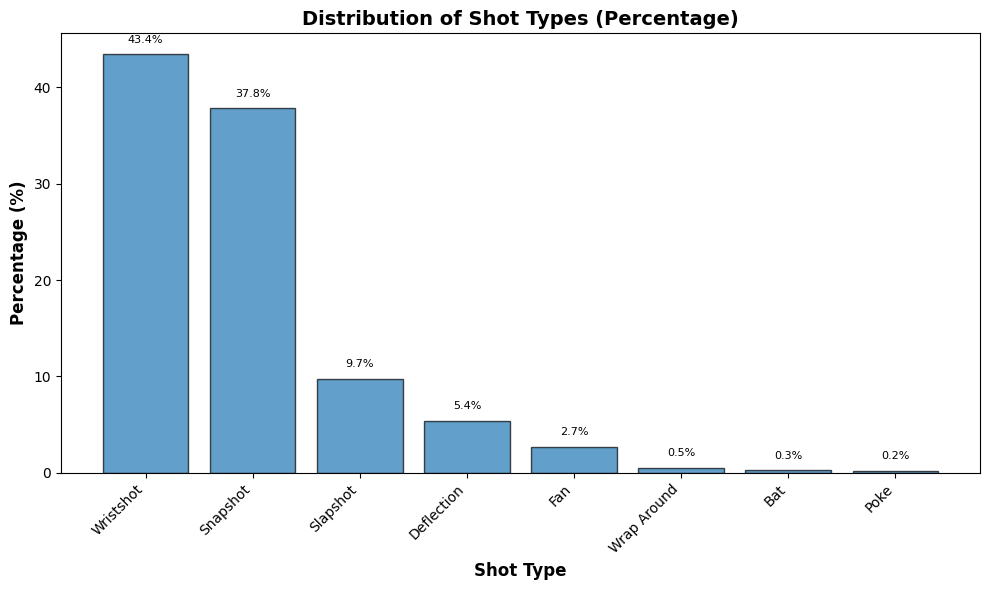

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with percentages
ax.bar(shot_types["Detail_1"], shot_types["pct"] * 100, color="#1f77b4", edgecolor="black", alpha=0.7)

# Customize the plot
ax.set_xlabel("Shot Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Shot Types (Percentage)", fontsize=14, fontweight="bold")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Add percentage labels on top of bars
for i, v in enumerate(shot_types["pct"]):
    ax.text(i, v * 100 + 1, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

# Save the figure
fig.savefig("shot_types_distribution.png", dpi=300, bbox_inches="tight")
print("Image saved as shot_types_distribution.png")

plt.show()

In [ ]:
gt_table = (
    GT(shot_outcomes)
    .tab_header(title="Distribution of shot outcomes in the dataset")
    .cols_label(
        Outcome="Shot Outcome",
        Description="Description",
        pct="% of Shots",
    )
    .fmt_percent("pct", decimals=1)
    .cols_width({"Outcome": "130px", "Description": "420px", "pct": "110px"})
)

# Save the table as a PNG
gt_table.save("shot_outcomes_table.png")
print("Table saved as shot_outcomes_table.png")

ImportError: Module selenium not found. Run the following to install.

`pip install selenium`

In [ ]:
gt_table = (
    GT(shot_outcomes)
    .tab_header(title="Distribution of shot outcomes in the dataset")
    .cols_label(
        Outcome="Shot Outcome",
        Description="Description",
        pct="% of Shots",
    )
    .fmt_percent("pct", decimals=1)
    .cols_width({"Outcome": "130px", "Description": "420px", "pct": "110px"})
)

# Save the table as a PNG
gt_table.save("shot_outcomes_table.png")
print("Table saved as shot_outcomes_table.png")

Table saved as shot_outcomes_table.png


In [ ]:
fig.savefig("shot_types_distribution.png", dpi=300, bbox_inches="tight")
print("Image saved as shot_types_distribution.png")

Image saved as shot_types_distribution.png


Image saved as shot_types_distribution.png


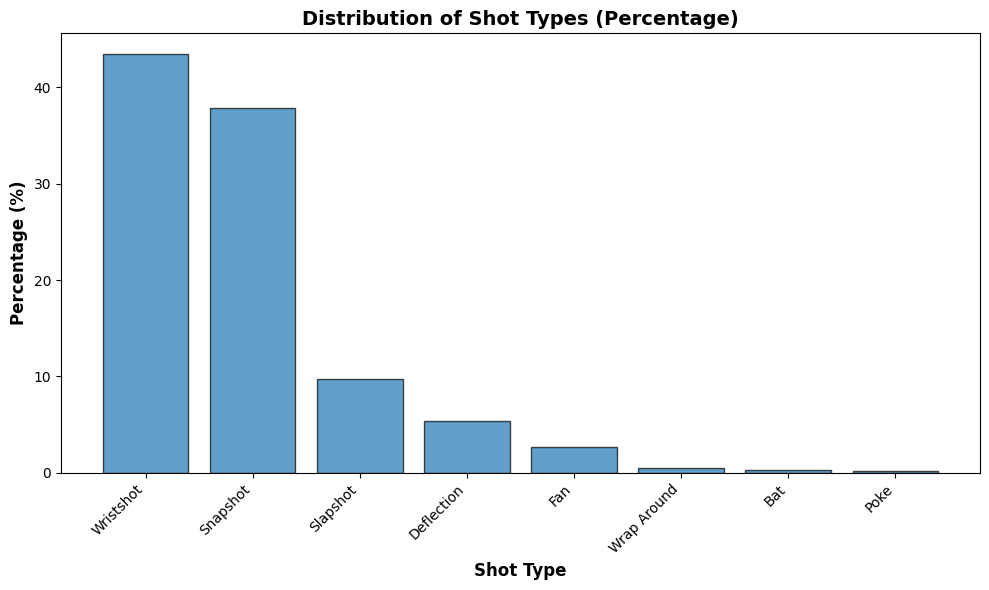

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with percentages (no labels on bars)
ax.bar(shot_types["Detail_1"], shot_types["pct"] * 100, color="#1f77b4", edgecolor="black", alpha=0.7)

# Customize the plot
ax.set_xlabel("Shot Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Shot Types (Percentage)", fontsize=14, fontweight="bold")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save the figure
fig.savefig("shot_types_distribution.png", dpi=300, bbox_inches="tight")
print("Image saved as shot_types_distribution.png")

plt.show()

Image saved as shot_types_distribution.png


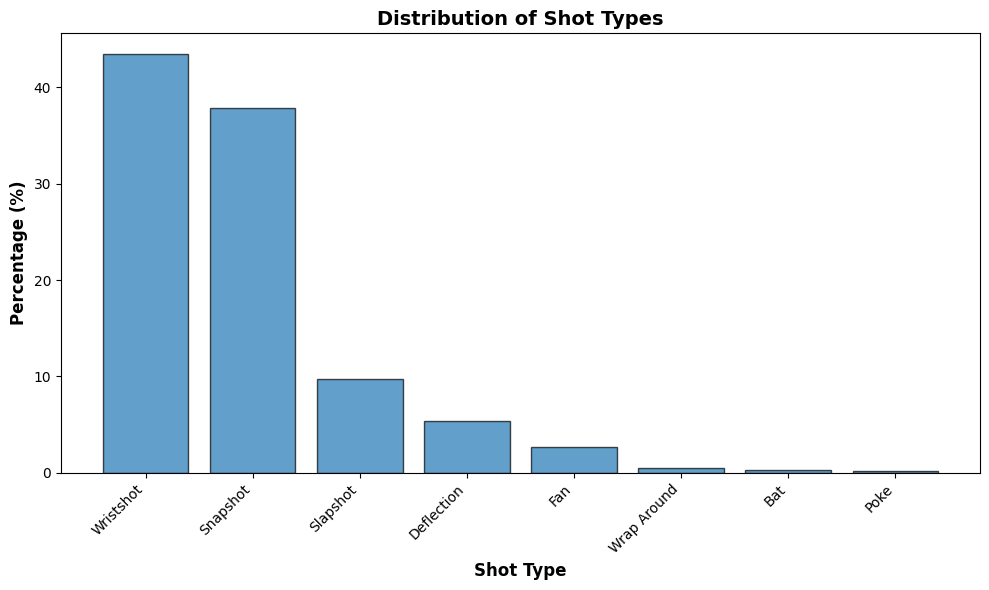

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with percentages (no labels on bars)
ax.bar(shot_types["Detail_1"], shot_types["pct"] * 100, color="#1f77b4", edgecolor="black", alpha=0.7)

# Customize the plot
ax.set_xlabel("Shot Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Shot Types", fontsize=14, fontweight="bold")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save the figure
fig.savefig("shot_types_distribution.png", dpi=300, bbox_inches="tight")
print("Image saved as shot_types_distribution.png")

plt.show()

In [ ]:

# Check columns in events and tracking
print("Events columns:")
print(events.columns)
print("\nTracking columns:")
print(tracking.columns)


Events columns:
['Date', 'Home_Team', 'Away_Team', 'Period', 'Clock', 'Clock_Seconds', 'Home_Team_Skaters', 'Away_Team_Skaters', 'Home_Team_Goals', 'Away_Team_Goals', 'Team', 'Player_Id', 'Event', 'X_Coordinate', 'Y_Coordinate', 'Detail_1', 'Detail_2', 'Detail_3', 'Detail_4', 'Player_Id_2', 'X_Coordinate_2', 'Y_Coordinate_2', 'Game']

Tracking columns:
['Image Id', 'Period', 'Game Clock', 'Game_Clock_Seconds', 'Player or Puck', 'Team', 'Player Jersey Number', 'Rink Location X (Feet)', 'Rink Location Y (Feet)', 'Rink Location Z (Feet)', 'Goal Score', 'Game']


In [ ]:

# Filter for shots and goals, select relevant columns
shots_display = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .select([
        "Date",
        "Home_Team",
        "Away_Team",
        "Period",
        "Clock",
        "Team",
        "Event",
        "Detail_1",
        "Detail_2",
        "X_Coordinate",
        "Y_Coordinate",
        "Home_Team_Goals",
        "Away_Team_Goals"
    ])
    .head(50)  # Show first 50 shots for the table
)

# Create GT table
gt_shots = (
    GT(shots_display)
    .tab_header(
        title="Shot and Goal Events",
        subtitle="First 50 shots/goals from the 2026 Big Data Cup"
    )
    .cols_label(
        Date="Date",
        Home_Team="Home Team",
        Away_Team="Away Team",
        Period="Period",
        Clock="Clock",
        Team="Shooting Team",
        Event="Event Type",
        Detail_1="Shot Type",
        Detail_2="Detail 2",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Home_Team_Goals="Home Goals",
        Away_Team_Goals="Away Goals"
    )
    .cols_width({
        "Date": "100px",
        "Home_Team": "100px",
        "Away_Team": "100px",
        "Period": "70px",
        "Clock": "80px",
        "Team": "100px",
        "Event": "80px",
        "Detail_1": "100px",
        "Detail_2": "100px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Home_Team_Goals": "90px",
        "Away_Team_Goals": "90px"
    })
)

gt_shots


GT(_tbl_data=shape: (50, 13)
┌─────────┬─────────┬─────────┬────────┬───┬─────────┬─────────┬─────────┬─────────┐
│ Date    ┆ Home_Te ┆ Away_Te ┆ Period ┆ … ┆ X_Coord ┆ Y_Coord ┆ Home_Te ┆ Away_Te │
│ ---     ┆ am      ┆ am      ┆ ---    ┆   ┆ inate   ┆ inate   ┆ am_Goal ┆ am_Goal │
│ str     ┆ ---     ┆ ---     ┆ i64    ┆   ┆ ---     ┆ ---     ┆ s       ┆ s       │
│         ┆ str     ┆ str     ┆        ┆   ┆ f64     ┆ f64     ┆ ---     ┆ ---     │
│         ┆         ┆         ┆        ┆   ┆         ┆         ┆ i64     ┆ i64     │
╞═════════╪═════════╪═════════╪════════╪═══╪═════════╪═════════╪═════════╪═════════╡
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 1      ┆ … ┆ 42.0    ┆ -30.5   ┆ 0       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 1      ┆ … ┆ -79.0   ┆ 8.5     ┆ 0       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 1      ┆ … ┆ -34.0   ┆ 23.5    ┆ 0       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 1      ┆ … ┆ -74.0   ┆ 3.5     ┆ 0       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 1      ┆ … ┆ -81.0   ┆ 0.5     ┆ 0       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ …       ┆ …       ┆ …       ┆ …      ┆ … ┆ …       ┆ …       ┆ …       ┆ …       │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 2      ┆ … ┆ -30.0   ┆ 7.5     ┆ 1       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 2      ┆ … ┆ -84.0   ┆ -10.5   ┆ 1       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 2      ┆ … ┆ 56.0    ┆ 16.5    ┆ 1       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 2      ┆ … ┆ -69.0   ┆ 29.5    ┆ 1       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
│ 2025-10 ┆ Team D  ┆ Team A  ┆ 2      ┆ … ┆ 86.0    ┆ 1.5     ┆ 2       ┆ 0       │
│ -11     ┆         ┆         ┆        ┆   ┆         ┆         ┆         ┆         │
└─────────┴─────────┴─────────┴────────┴───┴─────────┴─────────┴─────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x333362650>, _boxhead=Boxhead([ColInfo(var='Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='left', column_width='100px'), ColInfo(var='Home_Team', type=<ColInfoTypeEnum.default: 1>, column_label='Home Team', column_align='left', column_width='100px'), ColInfo(var='Away_Team', type=<ColInfoTypeEnum.default: 1>, column_label='Away Team', column_align='left', column_width='100px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='80px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Shooting Team', column_align='left', column_width='100px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event Type', column_align='left', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='100px'), ColInfo(var='Detail_2', type=<ColInfoTypeEnum.default: 1>, column_label='Detail 2', column_align='left', column_width='100px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Home_Team_Goals',

In [ ]:

# Create a summary tracking table - show player positions during shots
tracking_summary = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .select([
        "Game",
        "Period",
        "Game Clock",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)"
    ])
    .head(50)
)

# Create GT table for tracking data
gt_tracking = (
    GT(tracking_summary)
    .tab_header(
        title="Player Tracking Data",
        subtitle="First 50 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X (Feet)"},
        **{"Rink Location Y (Feet)": "Y (Feet)"},
        **{"Rink Location Z (Feet)": "Z (Feet)"}
    )
    .cols_width({
        "Game": "150px",
        "Period": "70px",
        "Game Clock": "80px",
        "Team": "80px",
        "Player Jersey Number": "80px",
        "Rink Location X (Feet)": "110px",
        "Rink Location Y (Feet)": "110px",
        "Rink Location Z (Feet)": "110px"
    })
)

gt_tracking


GT(_tbl_data=shape: (50, 8)
┌───────────┬────────┬───────┬──────┬───────────┬───────────┬───────────┬──────────┐
│ Game      ┆ Period ┆ Game  ┆ Team ┆ Player    ┆ Rink      ┆ Rink      ┆ Rink     │
│ ---       ┆ ---    ┆ Clock ┆ ---  ┆ Jersey    ┆ Location  ┆ Location  ┆ Location │
│ str       ┆ i64    ┆ ---   ┆ str  ┆ Number    ┆ X (Feet)  ┆ Y (Feet)  ┆ Z (Feet) │
│           ┆        ┆ str   ┆      ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆        ┆       ┆      ┆ str       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪════════╪═══════╪══════╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Home ┆ 52        ┆ -16.408   ┆ -11.735   ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Home ┆ 88        ┆ -17.285   ┆ 7.852     ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Home ┆ 8         ┆ -1.326    ┆ 13.505    ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Home ┆ 77        ┆ -1.401    ┆ -1.048    ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Home ┆ 42        ┆ 0.027     ┆ -13.059   ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ …         ┆ …      ┆ …     ┆ …    ┆ …         ┆ …         ┆ …         ┆ …        │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Away ┆ 48        ┆ 23.334    ┆ -12.187   ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Away ┆ 5         ┆ 20.59     ┆ 5.061     ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Away ┆ 92        ┆ 2.374     ┆ -13.492   ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Away ┆ 63        ┆ 1.708     ┆ -0.11     ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ 2025-10-1 ┆ 1      ┆ 20:00 ┆ Away ┆ 29        ┆ 1.529     ┆ 14.857    ┆ 1.0      │
│ 1.Team.A. ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
│ @.Team.D  ┆        ┆       ┆      ┆           ┆           ┆           ┆          │
└───────────┴────────┴───────┴──────┴───────────┴───────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x333343ce0>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='150px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='80px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='80px'), ColInfo(var='Player Jersey Number', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey

In [ ]:

# Save the shots/events table as PNG
gt_shots.save("shot_events_table.png")
print("Saved: shot_events_table.png")

# Save the tracking data table as PNG
gt_tracking.save("tracking_data_table.png")
print("Saved: tracking_data_table.png")


Saved: shot_events_table.png
Saved: tracking_data_table.png


In [ ]:

# Shot Events table - first 5 rows
shots_display_5 = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .select([
        "Date",
        "Home_Team",
        "Away_Team",
        "Period",
        "Clock",
        "Team",
        "Event",
        "Detail_1",
        "Detail_2",
        "X_Coordinate",
        "Y_Coordinate",
        "Home_Team_Goals",
        "Away_Team_Goals"
    ])
    .head(5)
)

gt_shots_5 = (
    GT(shots_display_5)
    .tab_header(
        title="Shot and Goal Events",
        subtitle="First 5 shots/goals from the 2026 Big Data Cup"
    )
    .cols_label(
        Date="Date",
        Home_Team="Home Team",
        Away_Team="Away Team",
        Period="Period",
        Clock="Clock",
        Team="Shooting Team",
        Event="Event Type",
        Detail_1="Shot Type",
        Detail_2="Detail 2",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Home_Team_Goals="Home Goals",
        Away_Team_Goals="Away Goals"
    )
    .cols_width({
        "Date": "100px",
        "Home_Team": "100px",
        "Away_Team": "100px",
        "Period": "70px",
        "Clock": "80px",
        "Team": "100px",
        "Event": "80px",
        "Detail_1": "100px",
        "Detail_2": "100px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Home_Team_Goals": "90px",
        "Away_Team_Goals": "90px"
    })
)

gt_shots_5


GT(_tbl_data=shape: (5, 13)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Dat ┆ Hom ┆ Awa ┆ Per ┆ … ┆ X_Coor ┆ Y_Coo ┆ Home_ ┆ Away_ │
│ e   ┆ e_T ┆ y_T ┆ iod ┆   ┆ dinate ┆ rdina ┆ Team_ ┆ Team_ │
│ --- ┆ eam ┆ eam ┆ --- ┆   ┆ ---    ┆ te    ┆ Goals ┆ Goals │
│ str ┆ --- ┆ --- ┆ i64 ┆   ┆ f64    ┆ ---   ┆ ---   ┆ ---   │
│     ┆ str ┆ str ┆     ┆   ┆        ┆ f64   ┆ i64   ┆ i64   │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ 42.0   ┆ -30.5 ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -79.0  ┆ 8.5   ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -34.0  ┆ 23.5  ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -74.0  ┆ 3.5   ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -81.0  ┆ 0.5   ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333a57690>, _boxhead=Boxhead([ColInfo(var='Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='left', column_width='100px'), ColInfo(var='Home_Team', type=<ColInfoTypeEnum.default: 1>, column_label='Home Team', column_align='left', column_width='100px'), ColInfo(var='Away_Team', type=<ColInfoTypeEnum.default: 1>, column_label='Away Team', column_align='left', column_width='100px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='80px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Shooting Team', column_align='left', column_width='100px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event Type', column_align='left', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='100px'), ColInfo(var='Detail_2', type=<ColInfoTypeEnum.default: 1>, column_label='Detail 2', column_align='left', column_width='100px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Home_Team_Goals', type=<ColInfoTypeEnum.default: 1>, column_label='Home Goals', column_align='right', column_width='90px'), ColInfo(var='Away_Team_Goals', type=<ColInfoTypeEnum.default: 1>, column_label='Away Goals', column_align='right', column_width='90px')]), _stub=<great_tables._gt_data.Stub object at 0x333ad7e10>, _spanners=Spanners([]), _heading=Heading(title='Shot and Goal Events', subtitle='First 5 shots/goals from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x333af6580>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x333af6ad0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale 

In [ ]:

# Tracking data table - first 5 rows
tracking_summary_5 = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .select([
        "Game",
        "Period",
        "Game Clock",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)"
    ])
    .head(5)
)

gt_tracking_5 = (
    GT(tracking_summary_5)
    .tab_header(
        title="Player Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X (Feet)"},
        **{"Rink Location Y (Feet)": "Y (Feet)"},
        **{"Rink Location Z (Feet)": "Z (Feet)"}
    )
    .cols_width({
        "Game": "150px",
        "Period": "70px",
        "Game Clock": "80px",
        "Team": "80px",
        "Player Jersey Number": "80px",
        "Rink Location X (Feet)": "110px",
        "Rink Location Y (Feet)": "110px",
        "Rink Location Z (Feet)": "110px"
    })
)

gt_tracking_5


GT(_tbl_data=shape: (5, 8)
┌─────┬─────┬────────┬──────┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Game   ┆ Team ┆ Player ┆ Rink  ┆ Rink  ┆ Rink  │
│ e   ┆ iod ┆ Clock  ┆ ---  ┆ Jersey ┆ Locat ┆ Locat ┆ Locat │
│ --- ┆ --- ┆ ---    ┆ str  ┆ Number ┆ ion X ┆ ion Y ┆ ion Z │
│ str ┆ i64 ┆ str    ┆      ┆ ---    ┆ (Feet ┆ (Feet ┆ (Feet │
│     ┆     ┆        ┆      ┆ str    ┆ )     ┆ )     ┆ )     │
│     ┆     ┆        ┆      ┆        ┆ ---   ┆ ---   ┆ ---   │
│     ┆     ┆        ┆      ┆        ┆ f64   ┆ f64   ┆ f64   │
╞═════╪═════╪════════╪══════╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 52     ┆ -16.4 ┆ -11.7 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 08    ┆ 35    ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 88     ┆ -17.2 ┆ 7.852 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 85    ┆       ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 8      ┆ -1.32 ┆ 13.50 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 6     ┆ 5     ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 77     ┆ -1.40 ┆ -1.04 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 1     ┆ 8     ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 42     ┆ 0.027 ┆ -13.0 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆       ┆ 59    ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
└─────┴─────┴────────┴──────┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x3338cbf50>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='150px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='80px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column

In [ ]:

# Update shot events table with new title
gt_shots_5_updated = (
    GT(shots_display_5)
    .tab_header(
        title="Events Data",
        subtitle="First 5 shots/goals from the 2026 Big Data Cup"
    )
    .cols_label(
        Date="Date",
        Home_Team="Home Team",
        Away_Team="Away Team",
        Period="Period",
        Clock="Clock",
        Team="Shooting Team",
        Event="Event Type",
        Detail_1="Shot Type",
        Detail_2="Detail 2",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Home_Team_Goals="Home Goals",
        Away_Team_Goals="Away Goals"
    )
    .cols_width({
        "Date": "100px",
        "Home_Team": "100px",
        "Away_Team": "100px",
        "Period": "70px",
        "Clock": "80px",
        "Team": "100px",
        "Event": "80px",
        "Detail_1": "100px",
        "Detail_2": "100px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Home_Team_Goals": "90px",
        "Away_Team_Goals": "90px"
    })
)

gt_shots_5_updated


GT(_tbl_data=shape: (5, 13)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Dat ┆ Hom ┆ Awa ┆ Per ┆ … ┆ X_Coor ┆ Y_Coo ┆ Home_ ┆ Away_ │
│ e   ┆ e_T ┆ y_T ┆ iod ┆   ┆ dinate ┆ rdina ┆ Team_ ┆ Team_ │
│ --- ┆ eam ┆ eam ┆ --- ┆   ┆ ---    ┆ te    ┆ Goals ┆ Goals │
│ str ┆ --- ┆ --- ┆ i64 ┆   ┆ f64    ┆ ---   ┆ ---   ┆ ---   │
│     ┆ str ┆ str ┆     ┆   ┆        ┆ f64   ┆ i64   ┆ i64   │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ 42.0   ┆ -30.5 ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -79.0  ┆ 8.5   ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -34.0  ┆ 23.5  ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -74.0  ┆ 3.5   ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ Tea ┆ Tea ┆ 1   ┆ … ┆ -81.0  ┆ 0.5   ┆ 0     ┆ 0     │
│ 5-1 ┆ m D ┆ m A ┆     ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1   ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333b4ab70>, _boxhead=Boxhead([ColInfo(var='Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='left', column_width='100px'), ColInfo(var='Home_Team', type=<ColInfoTypeEnum.default: 1>, column_label='Home Team', column_align='left', column_width='100px'), ColInfo(var='Away_Team', type=<ColInfoTypeEnum.default: 1>, column_label='Away Team', column_align='left', column_width='100px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='80px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Shooting Team', column_align='left', column_width='100px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event Type', column_align='left', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='100px'), ColInfo(var='Detail_2', type=<ColInfoTypeEnum.default: 1>, column_label='Detail 2', column_align='left', column_width='100px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Home_Team_Goals', type=<ColInfoTypeEnum.default: 1>, column_label='Home Goals', column_align='right', column_width='90px'), ColInfo(var='Away_Team_Goals', type=<ColInfoTypeEnum.default: 1>, column_label='Away Goals', column_align='right', column_width='90px')]), _stub=<great_tables._gt_data.Stub object at 0x3338085f0>, _spanners=Spanners([]), _heading=Heading(title='Events Data', subtitle='First 5 shots/goals from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x333b706e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x333b707d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at

In [ ]:

# Update tracking data table with new title
gt_tracking_5_updated = (
    GT(tracking_summary_5)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X (Feet)"},
        **{"Rink Location Y (Feet)": "Y (Feet)"},
        **{"Rink Location Z (Feet)": "Z (Feet)"}
    )
    .cols_width({
        "Game": "150px",
        "Period": "70px",
        "Game Clock": "80px",
        "Team": "80px",
        "Player Jersey Number": "80px",
        "Rink Location X (Feet)": "110px",
        "Rink Location Y (Feet)": "110px",
        "Rink Location Z (Feet)": "110px"
    })
)

gt_tracking_5_updated


GT(_tbl_data=shape: (5, 8)
┌─────┬─────┬────────┬──────┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Game   ┆ Team ┆ Player ┆ Rink  ┆ Rink  ┆ Rink  │
│ e   ┆ iod ┆ Clock  ┆ ---  ┆ Jersey ┆ Locat ┆ Locat ┆ Locat │
│ --- ┆ --- ┆ ---    ┆ str  ┆ Number ┆ ion X ┆ ion Y ┆ ion Z │
│ str ┆ i64 ┆ str    ┆      ┆ ---    ┆ (Feet ┆ (Feet ┆ (Feet │
│     ┆     ┆        ┆      ┆ str    ┆ )     ┆ )     ┆ )     │
│     ┆     ┆        ┆      ┆        ┆ ---   ┆ ---   ┆ ---   │
│     ┆     ┆        ┆      ┆        ┆ f64   ┆ f64   ┆ f64   │
╞═════╪═════╪════════╪══════╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 52     ┆ -16.4 ┆ -11.7 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 08    ┆ 35    ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 88     ┆ -17.2 ┆ 7.852 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 85    ┆       ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 8      ┆ -1.32 ┆ 13.50 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 6     ┆ 5     ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 77     ┆ -1.40 ┆ -1.04 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆ 1     ┆ 8     ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20:00  ┆ Home ┆ 42     ┆ 0.027 ┆ -13.0 ┆ 1.0   │
│ 5-1 ┆     ┆        ┆      ┆        ┆       ┆ 59    ┆       │
│ 0-1 ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ eam ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆        ┆      ┆        ┆       ┆       ┆       │
└─────┴─────┴────────┴──────┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333ab55d0>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='150px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='80px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column

In [ ]:

# Save both tables as PNG
gt_shots_5_updated.save("events_data_table.png")
print("Saved: events_data_table.png")

gt_tracking_5_updated.save("tracking_data_table.png")
print("Saved: tracking_data_table.png")


Saved: events_data_table.png
Saved: tracking_data_table.png


In [ ]:

# Tracking data table with additional columns to match events table size
tracking_summary_5_expanded = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .select([
        "Game",
        "Period",
        "Game Clock",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)",
        "Image Id",
        "Goal Score"
    ])
    .head(5)
)

gt_tracking_5_expanded = (
    GT(tracking_summary_5_expanded)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X (Feet)"},
        **{"Rink Location Y (Feet)": "Y (Feet)"},
        **{"Rink Location Z (Feet)": "Z (Feet)"},
        **{"Image Id": "Image ID"},
        **{"Goal Score": "Goal Score"}
    )
    .cols_width({
        "Game": "120px",
        "Period": "60px",
        "Game Clock": "70px",
        "Team": "70px",
        "Player Jersey Number": "70px",
        "Rink Location X (Feet)": "90px",
        "Rink Location Y (Feet)": "90px",
        "Rink Location Z (Feet)": "90px",
        "Image Id": "90px",
        "Goal Score": "90px"
    })
)

gt_tracking_5_expanded


GT(_tbl_data=shape: (5, 10)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Gam ┆ Tea ┆ … ┆ Rink   ┆ Rink  ┆ Image ┆ Goal  │
│ e   ┆ iod ┆ e   ┆ m   ┆   ┆ Locati ┆ Locat ┆ Id    ┆ Score │
│ --- ┆ --- ┆ Clo ┆ --- ┆   ┆ on Y   ┆ ion Z ┆ ---   ┆ ---   │
│ str ┆ i64 ┆ ck  ┆ str ┆   ┆ (Feet) ┆ (Feet ┆ str   ┆ str   │
│     ┆     ┆ --- ┆     ┆   ┆ ---    ┆ )     ┆       ┆       │
│     ┆     ┆ str ┆     ┆   ┆ f64    ┆ ---   ┆       ┆       │
│     ┆     ┆     ┆     ┆   ┆        ┆ f64   ┆       ┆       │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20: ┆ Hom ┆ … ┆ -11.73 ┆ 1.0   ┆ 2025- ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ e   ┆   ┆ 5      ┆       ┆ 10-11 ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ A @   ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆ D_065 ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ …     ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ Hom ┆ … ┆ 7.852  ┆ 1.0   ┆ 2025- ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ e   ┆   ┆        ┆       ┆ 10-11 ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ A @   ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆ D_065 ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ …     ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ Hom ┆ … ┆ 13.505 ┆ 1.0   ┆ 2025- ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ e   ┆   ┆        ┆       ┆ 10-11 ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ A @   ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆ D_065 ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ …     ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ Hom ┆ … ┆ -1.048 ┆ 1.0   ┆ 2025- ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ e   ┆   ┆        ┆       ┆ 10-11 ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ A @   ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆ D_065 ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ …     ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ Hom ┆ … ┆ -13.05 ┆ 1.0   ┆ 2025- ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ e   ┆   ┆ 9      ┆       ┆ 10-11 ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ A @   ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆ Team  ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆ D_065 ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆ …     ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333b6f3e0>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='120px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, colum

In [ ]:

# Save updated tracking data table with 10 columns
gt_tracking_5_expanded.save("tracking_data_table.png")
print("Saved: tracking_data_table.png (updated with 10 columns)")


Saved: tracking_data_table.png (updated with 10 columns)


In [ ]:

# Show all available columns in tracking data
print("Available columns in tracking data:")
print(tracking.columns)


Available columns in tracking data:
['Image Id', 'Period', 'Game Clock', 'Game_Clock_Seconds', 'Player or Puck', 'Team', 'Player Jersey Number', 'Rink Location X (Feet)', 'Rink Location Y (Feet)', 'Rink Location Z (Feet)', 'Goal Score', 'Game']


In [ ]:

# Tracking data table with Game_Clock_Seconds instead of Image ID
tracking_summary_5_expanded = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .select([
        "Game",
        "Period",
        "Game Clock",
        "Game_Clock_Seconds",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)",
        "Goal Score"
    ])
    .head(5)
)

gt_tracking_5_expanded = (
    GT(tracking_summary_5_expanded)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Seconds"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X (Feet)"},
        **{"Rink Location Y (Feet)": "Y (Feet)"},
        **{"Rink Location Z (Feet)": "Z (Feet)"},
        **{"Goal Score": "Goal Score"}
    )
    .cols_width({
        "Game": "120px",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "100px",
        "Team": "70px",
        "Player Jersey Number": "70px",
        "Rink Location X (Feet)": "90px",
        "Rink Location Y (Feet)": "90px",
        "Rink Location Z (Feet)": "90px",
        "Goal Score": "90px"
    })
)

gt_tracking_5_expanded


GT(_tbl_data=shape: (5, 10)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Gam ┆ Gam ┆ … ┆ Rink   ┆ Rink  ┆ Rink  ┆ Goal  │
│ e   ┆ iod ┆ e   ┆ e_C ┆   ┆ Locati ┆ Locat ┆ Locat ┆ Score │
│ --- ┆ --- ┆ Clo ┆ loc ┆   ┆ on X   ┆ ion Y ┆ ion Z ┆ ---   │
│ str ┆ i64 ┆ ck  ┆ k_S ┆   ┆ (Feet) ┆ (Feet ┆ (Feet ┆ str   │
│     ┆     ┆ --- ┆ eco ┆   ┆ ---    ┆ )     ┆ )     ┆       │
│     ┆     ┆ str ┆ nds ┆   ┆ f64    ┆ ---   ┆ ---   ┆       │
│     ┆     ┆     ┆ --- ┆   ┆        ┆ f64   ┆ f64   ┆       │
│     ┆     ┆     ┆ i64 ┆   ┆        ┆       ┆       ┆       │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -16.40 ┆ -11.7 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆ 8      ┆ 35    ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -17.28 ┆ 7.852 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆ 5      ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -1.326 ┆ 13.50 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆ 5     ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -1.401 ┆ -1.04 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆ 8     ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 0.027  ┆ -13.0 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆ 59    ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333b833e0>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='120px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'

In [ ]:

# Save updated tracking data table
gt_tracking_5_expanded.save("tracking_data_table.png")
print("Saved: tracking_data_table.png (with Clock Seconds instead of Image ID)")


Saved: tracking_data_table.png (with Clock Seconds instead of Image ID)


In [ ]:

# Tracking data table with adjusted column widths to match events table size
gt_tracking_5_adjusted = (
    GT(tracking_summary_5_expanded)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Goal Score"}
    )
    .cols_width({
        "Game": "100px",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "80px",
        "Team": "70px",
        "Player Jersey Number": "70px",
        "Rink Location X (Feet)": "70px",
        "Rink Location Y (Feet)": "70px",
        "Rink Location Z (Feet)": "70px",
        "Goal Score": "80px"
    })
)

gt_tracking_5_adjusted


GT(_tbl_data=shape: (5, 10)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Gam ┆ Gam ┆ … ┆ Rink   ┆ Rink  ┆ Rink  ┆ Goal  │
│ e   ┆ iod ┆ e   ┆ e_C ┆   ┆ Locati ┆ Locat ┆ Locat ┆ Score │
│ --- ┆ --- ┆ Clo ┆ loc ┆   ┆ on X   ┆ ion Y ┆ ion Z ┆ ---   │
│ str ┆ i64 ┆ ck  ┆ k_S ┆   ┆ (Feet) ┆ (Feet ┆ (Feet ┆ str   │
│     ┆     ┆ --- ┆ eco ┆   ┆ ---    ┆ )     ┆ )     ┆       │
│     ┆     ┆ str ┆ nds ┆   ┆ f64    ┆ ---   ┆ ---   ┆       │
│     ┆     ┆     ┆ --- ┆   ┆        ┆ f64   ┆ f64   ┆       │
│     ┆     ┆     ┆ i64 ┆   ┆        ┆       ┆       ┆       │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -16.40 ┆ -11.7 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆ 8      ┆ 35    ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -17.28 ┆ 7.852 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆ 5      ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -1.326 ┆ 13.50 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆ 5     ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ -1.401 ┆ -1.04 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆ 8     ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 0.027  ┆ -13.0 ┆ 1.0   ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆ 59    ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x10e7d2f80>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='100px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'

In [ ]:

# Save the adjusted tracking data table
gt_tracking_5_adjusted.save("tracking_data_table.png")
print("Saved: tracking_data_table.png (with adjusted column widths)")


Saved: tracking_data_table.png (with adjusted column widths)


In [ ]:

# Create tracking data with more columns to match events data (13 columns)
tracking_summary_5_full = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .select([
        "Game",
        "Period",
        "Game Clock",
        "Game_Clock_Seconds",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)",
        "Goal Score",
        "Player or Puck"
    ])
    .head(5)
)

print(f"Tracking table currently has {len(tracking_summary_5_full.columns)} columns")
print(f"Events table has 13 columns")
print(f"Columns: {tracking_summary_5_full.columns}")


Tracking table currently has 11 columns
Events table has 13 columns
Columns: ['Game', 'Period', 'Game Clock', 'Game_Clock_Seconds', 'Team', 'Player Jersey Number', 'Rink Location X (Feet)', 'Rink Location Y (Feet)', 'Rink Location Z (Feet)', 'Goal Score', 'Player or Puck']


In [ ]:

# Create tracking data with 13 columns to match events data
# Join tracking with events to get additional context
tracking_with_events = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .join(
        events.select([
            "Date",
            "Home_Team",
            "Away_Team",
            "Period",
            "Clock",
            "Team",
            "Event"
        ]).filter(pl.col("Event").is_in(["Shot", "Goal"])),
        on=["Period", "Team"],
        how="left"
    )
    .select([
        "Game",
        "Period",
        "Game Clock",
        "Game_Clock_Seconds",
        "Date",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)",
        "Goal Score",
        "Home_Team",
        "Away_Team"
    ])
    .head(5)
)

gt_tracking_13_col = (
    GT(tracking_with_events)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Date="Date",
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Score"},
        Home_Team="Home",
        Away_Team="Away"
    )
    .cols_width({
        "Game": "90px",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "75px",
        "Date": "85px",
        "Team": "65px",
        "Player Jersey Number": "65px",
        "Rink Location X (Feet)": "60px",
        "Rink Location Y (Feet)": "60px",
        "Rink Location Z (Feet)": "60px",
        "Goal Score": "60px",
        "Home_Team": "70px",
        "Away_Team": "70px"
    })
)

gt_tracking_13_col


GT(_tbl_data=shape: (5, 13)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Gam ┆ Gam ┆ … ┆ Rink   ┆ Goal  ┆ Home_ ┆ Away_ │
│ e   ┆ iod ┆ e   ┆ e_C ┆   ┆ Locati ┆ Score ┆ Team  ┆ Team  │
│ --- ┆ --- ┆ Clo ┆ loc ┆   ┆ on Z   ┆ ---   ┆ ---   ┆ ---   │
│ str ┆ i64 ┆ ck  ┆ k_S ┆   ┆ (Feet) ┆ str   ┆ str   ┆ str   │
│     ┆     ┆ --- ┆ eco ┆   ┆ ---    ┆       ┆       ┆       │
│     ┆     ┆ str ┆ nds ┆   ┆ f64    ┆       ┆       ┆       │
│     ┆     ┆     ┆ --- ┆   ┆        ┆       ┆       ┆       │
│     ┆     ┆     ┆ i64 ┆   ┆        ┆       ┆       ┆       │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333b82fd0>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='90px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px')

In [ ]:

# Save the 13-column tracking data table
gt_tracking_13_col.save("tracking_data_table.png")
print("Saved: tracking_data_table.png (now with 13 columns matching Events Data)")


Saved: tracking_data_table.png (now with 13 columns matching Events Data)


In [ ]:

# Create tracking data table with auto-fit columns
gt_tracking_13_col_autofit = (
    GT(tracking_with_events)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Date="Date",
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Score"},
        Home_Team="Home",
        Away_Team="Away"
    )
    .tab_options(table_layout="auto")
)

gt_tracking_13_col_autofit


GT(_tbl_data=shape: (5, 13)
┌─────┬─────┬─────┬─────┬───┬────────┬───────┬───────┬───────┐
│ Gam ┆ Per ┆ Gam ┆ Gam ┆ … ┆ Rink   ┆ Goal  ┆ Home_ ┆ Away_ │
│ e   ┆ iod ┆ e   ┆ e_C ┆   ┆ Locati ┆ Score ┆ Team  ┆ Team  │
│ --- ┆ --- ┆ Clo ┆ loc ┆   ┆ on Z   ┆ ---   ┆ ---   ┆ ---   │
│ str ┆ i64 ┆ ck  ┆ k_S ┆   ┆ (Feet) ┆ str   ┆ str   ┆ str   │
│     ┆     ┆ --- ┆ eco ┆   ┆ ---    ┆       ┆       ┆       │
│     ┆     ┆ str ┆ nds ┆   ┆ f64    ┆       ┆       ┆       │
│     ┆     ┆     ┆ --- ┆   ┆        ┆       ┆       ┆       │
│     ┆     ┆     ┆ i64 ┆   ┆        ┆       ┆       ┆       │
╞═════╪═════╪═════╪═════╪═══╪════════╪═══════╪═══════╪═══════╡
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 202 ┆ 1   ┆ 20: ┆ 120 ┆ … ┆ 1.0    ┆ null  ┆ null  ┆ null  │
│ 5-1 ┆     ┆ 00  ┆ 0   ┆   ┆        ┆       ┆       ┆       │
│ 0-1 ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ 1.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .A. ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ @.T ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ eam ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
│ .D  ┆     ┆     ┆     ┆   ┆        ┆       ┆       ┆       │
└─────┴─────┴─────┴─────┴───┴────────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x333ccf610>, _boxhead=Boxhead([ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width=None), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width=None), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width=None), ColI

In [ ]:

# Save the tracking data table with auto-fit columns
gt_tracking_13_col_autofit.save("tracking_data_table.png")
print("Saved: tracking_data_table.png (with auto-fit columns)")


Saved: tracking_data_table.png (with auto-fit columns)


In [ ]:

# Filter for Goals only and prepare data
goals_data = (
    events
    .filter(pl.col("Event") == "Goal")
    .with_columns(
        # Normalize all goals to the right side
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Compute shot angle
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / 3.141592653589793)
        ).alias("Shot_Angle")
    )
    .select("X_Coordinate", "Y_Coordinate", "Shot_Angle", "Detail_1")
)

print(f"Total goals: {len(goals_data)}")
goals_data.head(10)


Total goals: 58


X_Coordinate,Y_Coordinate,Shot_Angle,Detail_1
f64,f64,f64,str
87.0,1.5,36.869898,"""Wristshot"""
69.0,-29.5,55.86406,"""Wristshot"""
86.0,1.5,26.565051,"""Deflection"""
78.0,12.5,48.652223,"""Wristshot"""
83.0,-1.5,14.036243,"""Wristshot"""
84.0,2.5,26.565051,"""Deflection"""
78.0,2.5,12.804266,"""Snapshot"""
80.0,3.5,21.250506,"""Snapshot"""
87.0,3.5,60.255119,"""Wristshot"""


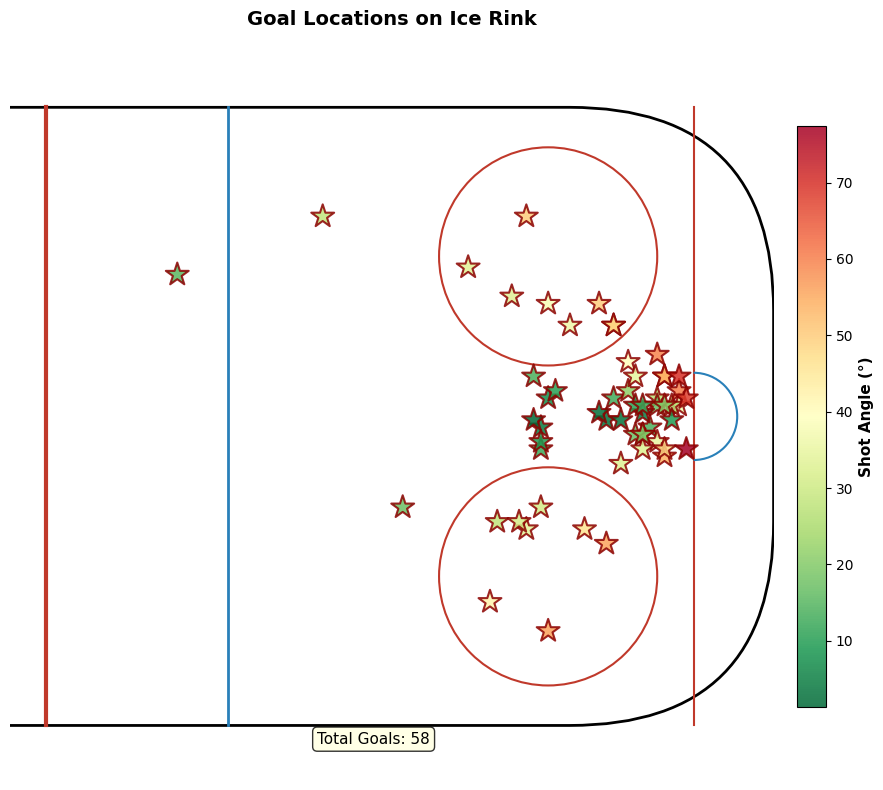

In [ ]:

from matplotlib.patches import Arc, Circle, FancyBboxPatch
import matplotlib.colors as mcolors

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#e8f4fb")

# --- Draw the rink ---
# Rink outline with rounded corners
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))

# Center red line
ax.plot([0, 0], [-42.5, 42.5], color="#c0392b", linewidth=3, zorder=2, label="Center Line")

# Blue lines (offensive zone)
ax.plot([25, 25], [-42.5, 42.5], color="#2980b9", linewidth=2, zorder=2, label="Blue Line")
ax.plot([89, 89], [-42.5, 42.5], color="#c0392b", linewidth=1.5, zorder=2, label="Goal Line")

# Circles at the face-off spots
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))

# Goal crease area
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot goals ---
cmap = plt.cm.RdYlGn_r
angles = goals_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

scatter = ax.scatter(
    goals_data.get_column("X_Coordinate").to_list(),
    goals_data.get_column("Y_Coordinate").to_list(),
    c=angles,
    cmap=cmap,
    norm=norm,
    s=300,
    marker="*",
    zorder=5,
    edgecolors="darkred",
    linewidths=1.5,
    alpha=0.85,
    label="Goals"
)

# --- Colorbar for shot angle ---
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Shot Angle (°)", fontsize=11, fontweight="bold")

# --- Labels and formatting ---
ax.set_xlim(-5, 100)
ax.set_ylim(-50, 50)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Goal Locations on Ice Rink", fontsize=14, fontweight="bold", pad=20)

# Add text annotation
ax.text(45, -45, f"Total Goals: {len(goals_data)}", fontsize=11, ha="center", 
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()


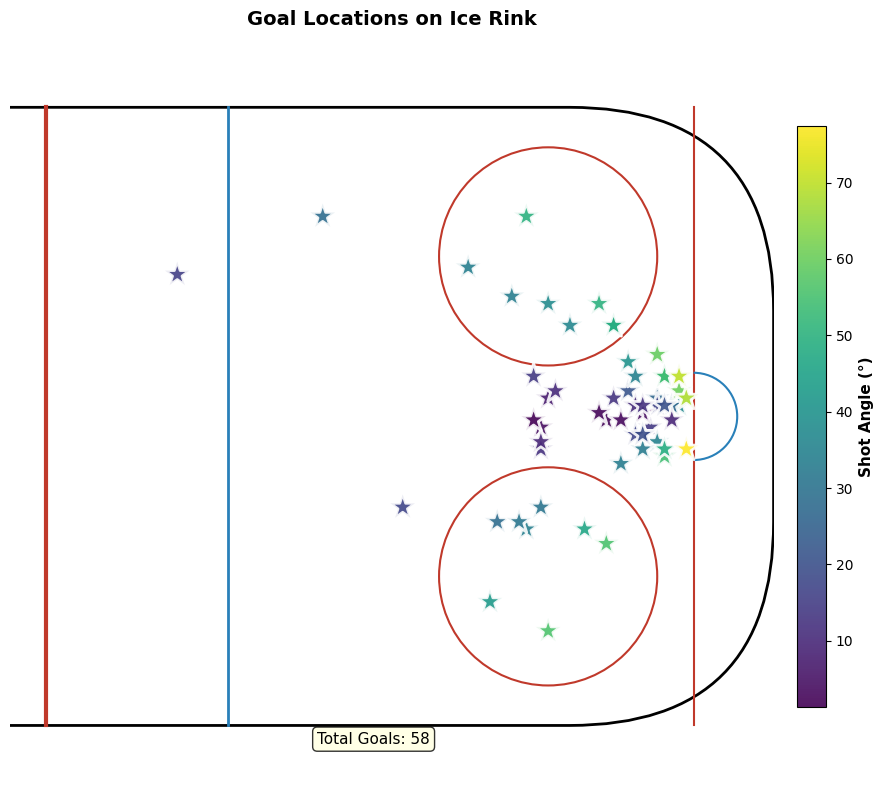

In [ ]:

from matplotlib.patches import Arc, Circle, FancyBboxPatch
import matplotlib.colors as mcolors

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#e8f4fb")

# --- Draw the rink ---
# Rink outline with rounded corners
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))

# Center red line
ax.plot([0, 0], [-42.5, 42.5], color="#c0392b", linewidth=3, zorder=2, label="Center Line")

# Blue lines (offensive zone)
ax.plot([25, 25], [-42.5, 42.5], color="#2980b9", linewidth=2, zorder=2, label="Blue Line")
ax.plot([89, 89], [-42.5, 42.5], color="#c0392b", linewidth=1.5, zorder=2, label="Goal Line")

# Circles at the face-off spots
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))

# Goal crease area
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot goals with improved color scheme ---
# Use viridis colormap for better range visibility
cmap = plt.cm.viridis
angles = goals_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

scatter = ax.scatter(
    goals_data.get_column("X_Coordinate").to_list(),
    goals_data.get_column("Y_Coordinate").to_list(),
    c=angles,
    cmap=cmap,
    norm=norm,
    s=350,
    marker="*",
    zorder=5,
    edgecolors="white",
    linewidths=2,
    alpha=0.9,
    label="Goals"
)

# --- Colorbar for shot angle ---
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Shot Angle (°)", fontsize=11, fontweight="bold")

# --- Labels and formatting ---
ax.set_xlim(-5, 100)
ax.set_ylim(-50, 50)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Goal Locations on Ice Rink", fontsize=14, fontweight="bold", pad=20)

# Add text annotation
ax.text(45, -45, f"Total Goals: {len(goals_data)}", fontsize=11, ha="center", 
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()


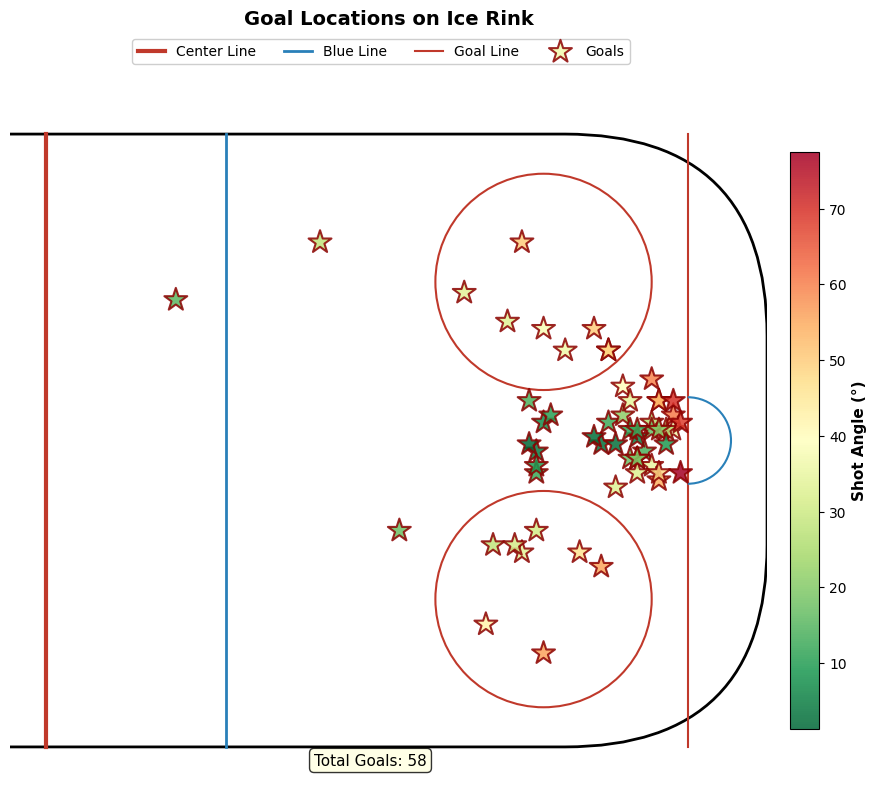

In [ ]:

from matplotlib.patches import Arc, Circle, FancyBboxPatch
import matplotlib.colors as mcolors

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#e8f4fb")

# --- Draw the rink ---
# Rink outline with rounded corners
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))

# Center red line
ax.plot([0, 0], [-42.5, 42.5], color="#c0392b", linewidth=3, zorder=2, label="Center Line")

# Blue lines (offensive zone)
ax.plot([25, 25], [-42.5, 42.5], color="#2980b9", linewidth=2, zorder=2, label="Blue Line")
ax.plot([89, 89], [-42.5, 42.5], color="#c0392b", linewidth=1.5, zorder=2, label="Goal Line")

# Circles at the face-off spots
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))

# Goal crease area
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot goals ---
cmap = plt.cm.RdYlGn_r
angles = goals_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

scatter = ax.scatter(
    goals_data.get_column("X_Coordinate").to_list(),
    goals_data.get_column("Y_Coordinate").to_list(),
    c=angles,
    cmap=cmap,
    norm=norm,
    s=300,
    marker="*",
    zorder=5,
    edgecolors="darkred",
    linewidths=1.5,
    alpha=0.85,
    label="Goals"
)

# --- Colorbar for shot angle ---
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Shot Angle (°)", fontsize=11, fontweight="bold")

# --- Labels and formatting ---
ax.set_xlim(-5, 100)
ax.set_ylim(-50, 50)
ax.set_aspect("equal")
ax.axis("off")

# Create title with legend below it
ax.set_title("Goal Locations on Ice Rink", fontsize=14, fontweight="bold", pad=40)

# Add legend horizontally below the title
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.98), 
           frameon=True, fontsize=10, framealpha=0.95)

# Add text annotation
ax.text(45, -45, f"Total Goals: {len(goals_data)}", fontsize=11, ha="center", 
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


<positron-console-cell-33>:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


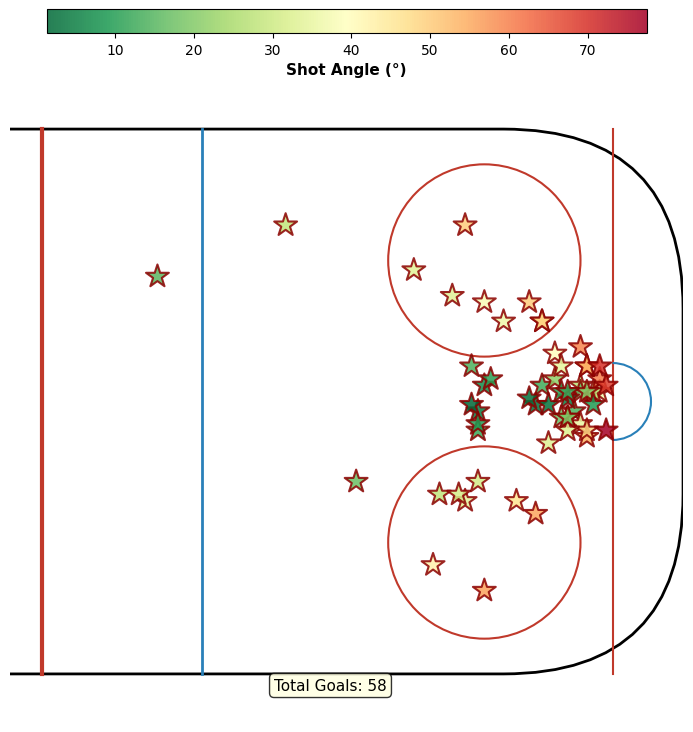

In [ ]:

from matplotlib.patches import Arc, Circle, FancyBboxPatch
import matplotlib.colors as mcolors

# Create figure with extra space at top
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#e8f4fb")

# --- Draw the rink ---
# Rink outline with rounded corners
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))

# Center red line
ax.plot([0, 0], [-42.5, 42.5], color="#c0392b", linewidth=3, zorder=2, label="Center Line")

# Blue lines (offensive zone)
ax.plot([25, 25], [-42.5, 42.5], color="#2980b9", linewidth=2, zorder=2, label="Blue Line")
ax.plot([89, 89], [-42.5, 42.5], color="#c0392b", linewidth=1.5, zorder=2, label="Goal Line")

# Circles at the face-off spots
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))

# Goal crease area
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot goals ---
cmap = plt.cm.RdYlGn_r
angles = goals_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

scatter = ax.scatter(
    goals_data.get_column("X_Coordinate").to_list(),
    goals_data.get_column("Y_Coordinate").to_list(),
    c=angles,
    cmap=cmap,
    norm=norm,
    s=300,
    marker="*",
    zorder=5,
    edgecolors="darkred",
    linewidths=1.5,
    alpha=0.85,
    label="Goals"
)

# --- Labels and formatting ---
ax.set_xlim(-5, 100)
ax.set_ylim(-50, 50)
ax.set_aspect("equal")
ax.axis("off")

ax.set_title("Goal Locations on Ice Rink", fontsize=14, fontweight="bold", pad=40)

# --- Horizontal colorbar below the title ---
cbar_ax = fig.add_axes([0.25, 0.88, 0.5, 0.03])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Shot Angle (°)", fontsize=11, fontweight="bold")

# Add text annotation
ax.text(45, -45, f"Total Goals: {len(goals_data)}", fontsize=11, ha="center", 
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.82)
plt.show()


In [ ]:

# Save the goal location plot
fig.savefig("goal_locations_ice_rink.png", dpi=300, bbox_inches="tight")
print("Saved: goal_locations_ice_rink.png")


Saved: goal_locations_ice_rink.png


In [ ]:
# Check available columns in tracking data
tracking.columns

['Image Id',
 'Period',
 'Game Clock',
 'Game_Clock_Seconds',
 'Player or Puck',
 'Team',
 'Player Jersey Number',
 'Rink Location X (Feet)',
 'Rink Location Y (Feet)',
 'Rink Location Z (Feet)',
 'Goal Score',
 'Game']

In [ ]:
# Create tracking data with Image Id column included
tracking_with_events = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .join(
        events.select([
            "Date",
            "Home_Team",
            "Away_Team",
            "Period",
            "Clock",
            "Team",
            "Event"
        ]).filter(pl.col("Event").is_in(["Shot", "Goal"])),
        on=["Period", "Team"],
        how="left"
    )
    .select([
        "Image Id",
        "Game",
        "Period",
        "Game Clock",
        "Game_Clock_Seconds",
        "Date",
        "Team",
        "Player Jersey Number",
        "Rink Location X (Feet)",
        "Rink Location Y (Feet)",
        "Rink Location Z (Feet)",
        "Goal Score",
        "Home_Team",
        "Away_Team"
    ])
    .head(5)
)

gt_tracking_13_col = (
    GT(tracking_with_events)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        **{"Image Id": "Image ID"},
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Date="Date",
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Score"},
        Home_Team="Home",
        Away_Team="Away"
    )
    .cols_width({
        "Image Id": "75px",
        "Game": "90px",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "75px",
        "Date": "85px",
        "Team": "65px",
        "Player Jersey Number": "65px",
        "Rink Location X (Feet)": "60px",
        "Rink Location Y (Feet)": "60px",
        "Rink Location Z (Feet)": "60px",
        "Goal Score": "60px",
        "Home_Team": "70px",
        "Away_Team": "70px"
    })
)

gt_tracking_13_col

GT(_tbl_data=shape: (5, 14)
┌─────────────┬────────────┬────────┬───────┬───┬────────────┬────────────┬───────────┬───────────┐
│ Image Id    ┆ Game       ┆ Period ┆ Game  ┆ … ┆ Rink       ┆ Goal Score ┆ Home_Team ┆ Away_Team │
│ ---         ┆ ---        ┆ ---    ┆ Clock ┆   ┆ Location Z ┆ ---        ┆ ---       ┆ ---       │
│ str         ┆ str        ┆ i64    ┆ ---   ┆   ┆ (Feet)     ┆ str        ┆ str       ┆ str       │
│             ┆            ┆        ┆ str   ┆   ┆ ---        ┆            ┆           ┆           │
│             ┆            ┆        ┆       ┆   ┆ f64        ┆            ┆           ┆           │
╞═════════════╪════════════╪════════╪═══════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 2025-10-11  ┆ 2025-10-11 ┆ 1      ┆ 20:00 ┆ … ┆ 1.0        ┆ null       ┆ null      ┆ null      │
│ Team A @    ┆ .Team.A.@. ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ Team D_065… ┆ Team.D     ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ 2025-10-11  ┆ 2025-10-11 ┆ 1      ┆ 20:00 ┆ … ┆ 1.0        ┆ null       ┆ null      ┆ null      │
│ Team A @    ┆ .Team.A.@. ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ Team D_065… ┆ Team.D     ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ 2025-10-11  ┆ 2025-10-11 ┆ 1      ┆ 20:00 ┆ … ┆ 1.0        ┆ null       ┆ null      ┆ null      │
│ Team A @    ┆ .Team.A.@. ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ Team D_065… ┆ Team.D     ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ 2025-10-11  ┆ 2025-10-11 ┆ 1      ┆ 20:00 ┆ … ┆ 1.0        ┆ null       ┆ null      ┆ null      │
│ Team A @    ┆ .Team.A.@. ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ Team D_065… ┆ Team.D     ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ 2025-10-11  ┆ 2025-10-11 ┆ 1      ┆ 20:00 ┆ … ┆ 1.0        ┆ null       ┆ null      ┆ null      │
│ Team A @    ┆ .Team.A.@. ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
│ Team D_065… ┆ Team.D     ┆        ┆       ┆   ┆            ┆            ┆           ┆           │
└─────────────┴────────────┴────────┴───────┴───┴────────────┴────────────┴───────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x372aa2360>, _boxhead=Boxhead([ColInfo(var='Image Id', type=<ColInfoTypeEnum.default: 1>, column_label='Image ID', column_align='left', column_width='75px'), ColInfo(var='Game', type=<ColInfoTypeEnum.default: 1>, column_label='Game', column_align='left', column_width='90px'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Game Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Game_Clock_Seconds', type=<ColInfoTypeEnum.default: 1>, column_label='Clock Sec', column_align='right', column_width='75px'), ColInfo(var='Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='left', column_width='85px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='65px'), ColInfo(var='Player Jersey Number', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey #', column_align='left', column_width='65px'), ColInfo(var='Rink Location X (Feet)', type=<ColInfoTypeEnum.default: 1>, column_label='X', column_align='right', column_width='60px'), ColInfo(var='Rink Location Y (Feet)', type=<ColInfoTypeEnum.default: 1>, column_label='Y', column_align='right', column_width='60px'), ColInfo(var='Rink Location Z (Feet)', type=<ColInfoTypeEnum.default: 1>, column_label='Z', column_align='right', column_width='60px'), ColInfo(var='Goal Score', type=<ColInfoTypeEnum.default: 1>, column_label='Score', column_align='left', column_width='60px'), ColInfo(var='Home_Team', type=<ColInfoTypeEnum.defau

In [ ]:
# Remove Date column and save as PNG
tracking_with_events_no_date = tracking_with_events.drop("Date")

gt_tracking_final = (
    GT(tracking_with_events_no_date)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        **{"Image Id": "Image ID"},
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Score"},
        Home_Team="Home",
        Away_Team="Away"
    )
    .cols_width({
        "Image Id": "75px",
        "Game": "90px",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "75px",
        "Team": "65px",
        "Player Jersey Number": "65px",
        "Rink Location X (Feet)": "60px",
        "Rink Location Y (Feet)": "60px",
        "Rink Location Z (Feet)": "60px",
        "Goal Score": "60px",
        "Home_Team": "70px",
        "Away_Team": "70px"
    })
)

# Save as PNG
gt_tracking_final.save("tracking_table.png")
print("GT table saved as tracking_table.png")

GT table saved as tracking_table.png


In [ ]:
# Update Image ID column width and save as PNG
gt_tracking_final = (
    GT(tracking_with_events_no_date)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        **{"Image Id": "Image ID"},
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Score"},
        Home_Team="Home",
        Away_Team="Away"
    )
    .cols_width({
        "Image Id": "200px",
        "Game": "90px",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "75px",
        "Team": "65px",
        "Player Jersey Number": "65px",
        "Rink Location X (Feet)": "60px",
        "Rink Location Y (Feet)": "60px",
        "Rink Location Z (Feet)": "60px",
        "Goal Score": "60px",
        "Home_Team": "70px",
        "Away_Team": "70px"
    })
)

# Save as PNG
gt_tracking_final.save("tracking_table.png")
print("GT table saved as tracking_table.png with wider Image ID column")

GT table saved as tracking_table.png with wider Image ID column


In [ ]:
# Auto-adjust column widths using cols_width with auto
gt_tracking_final = (
    GT(tracking_with_events_no_date)
    .tab_header(
        title="Tracking Data",
        subtitle="First 5 player position records from the 2026 Big Data Cup"
    )
    .cols_label(
        **{"Image Id": "Image ID"},
        Game="Game",
        Period="Period",
        **{"Game Clock": "Clock"},
        **{"Game_Clock_Seconds": "Clock Sec"},
        Team="Team",
        **{"Player Jersey Number": "Jersey #"},
        **{"Rink Location X (Feet)": "X"},
        **{"Rink Location Y (Feet)": "Y"},
        **{"Rink Location Z (Feet)": "Z"},
        **{"Goal Score": "Score"},
        Home_Team="Home",
        Away_Team="Away"
    )
    .cols_width({
        "Image Id": "200px",
        "Game": "auto",
        "Period": "60px",
        "Game Clock": "70px",
        "Game_Clock_Seconds": "75px",
        "Team": "65px",
        "Player Jersey Number": "65px",
        "Rink Location X (Feet)": "auto",
        "Rink Location Y (Feet)": "auto",
        "Rink Location Z (Feet)": "60px",
        "Goal Score": "60px",
        "Home_Team": "70px",
        "Away_Team": "70px"
    })
)

# Save as PNG
gt_tracking_final.save("tracking_table.png")
print("GT table saved with auto-adjusted widths for Game and X/Y columns")

GT table saved with auto-adjusted widths for Game and X/Y columns


In [33]:
# Check all columns in shot_speeds
shot_speeds.columns

['shot_id',
 'Date',
 'Home_Team',
 'Away_Team',
 'Period',
 'Clock',
 'Clock_Seconds',
 'Home_Team_Skaters',
 'Away_Team_Skaters',
 'Home_Team_Goals',
 'Away_Team_Goals',
 'Team',
 'Player_Id',
 'Event',
 'X_Coordinate',
 'Y_Coordinate',
 'Detail_1',
 'Detail_2',
 'Detail_3',
 'Detail_4',
 'Player_Id_2',
 'X_Coordinate_2',
 'Y_Coordinate_2',
 'Game',
 'Track_Team',
 'Frame',
 'match_dist',
 'used_flip',
 'speed_fps',
 'speed_fps_window_median',
 'n_candidates',
 'shooter_speed_fps',
 'match_quality',
 'shooter_speed_mph']

In [22]:
# Create GT table for shot_speeds with shooter speed in ft/s
shot_speeds_table = (
    shot_speeds
    .select([
        "shot_id",
        "Clock",
        "Player_Id",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "shooter_speed_fps"
    ])
    .with_columns(
        pl.col("shooter_speed_fps").round(1)
    )
    .head(5)
)

gt_shot_speeds = (
    GT(shot_speeds_table)
    .tab_header(
        title="Shot Speeds",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Clock="Clock",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        shooter_speed_fps="Speed (ft/s)"
    )
    .cols_width({
        "shot_id": "70px",
        "Clock": "70px",
        "Player_Id": "75px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "shooter_speed_fps": "110px"
    })
)

gt_shot_speeds

NameError: name 'shot_speeds' is not defined

In [21]:
# Create GT table with shooter_speed_fps rounded to 1 decimal place
shot_speeds_table = (
    shot_speeds
    .select([
        "shot_id",
        "Clock",
        "Player_Id",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "shooter_speed_fps"
    ])
    .with_columns(
        pl.col("shooter_speed_fps").round(1)
    )
    .head(5)
)

gt_shot_speeds = (
    GT(shot_speeds_table)
    .tab_header(
        title="Shot Speeds",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Clock="Clock",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        shooter_speed_fps="Speed (ft/s)"
    )
    .cols_width({
        "shot_id": "70px",
        "Clock": "70px",
        "Player_Id": "75px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "shooter_speed_fps": "100px"
    })
)

gt_shot_speeds

NameError: name 'shot_speeds' is not defined

In [36]:
# Create GT table with Frame and Team columns added
shot_speeds_table = (
    shot_speeds
    .select([
        "shot_id",
        "Clock",
        "Frame",
        "Team",
        "Player_Id",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "shooter_speed_mph"
    ])
    .with_columns(
        pl.col("shooter_speed_mph").round(1)
    )
    .head(5)
)

gt_shot_speeds = (
    GT(shot_speeds_table)
    .tab_header(
        title="Shot Speeds",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Clock="Clock",
        Frame="Frame",
        Team="Team",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        shooter_speed_mph="Speed (mph)"
    )
    .cols_width({
        "shot_id": "70px",
        "Clock": "70px",
        "Frame": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "shooter_speed_mph": "100px"
    })
)

gt_shot_speeds

GT(_tbl_data=shape: (5, 9)
┌─────────┬───────┬───────┬────────┬───┬──────────────┬──────────────┬────────────┬───────────────────┐
│ shot_id ┆ Clock ┆ Frame ┆ Team   ┆ … ┆ X_Coordinate ┆ Y_Coordinate ┆ Detail_1   ┆ shooter_speed_mph │
│ ---     ┆ ---   ┆ ---   ┆ ---    ┆   ┆ ---          ┆ ---          ┆ ---        ┆ ---               │
│ u32     ┆ str   ┆ i64   ┆ str    ┆   ┆ f64          ┆ f64          ┆ str        ┆ f64               │
╞═════════╪═══════╪═══════╪════════╪═══╪══════════════╪══════════════╪════════════╪═══════════════════╡
│ 0       ┆ 19:54 ┆ 65668 ┆ Team D ┆ … ┆ 42.0         ┆ -30.5        ┆ Wristshot  ┆ 15.0              │
│ 1       ┆ 19:26 ┆ 66490 ┆ Team A ┆ … ┆ -79.0        ┆ 8.5          ┆ Wristshot  ┆ 13.7              │
│ 2       ┆ 19:16 ┆ 66824 ┆ Team A ┆ … ┆ -34.0        ┆ 23.5         ┆ Wristshot  ┆ 3.0               │
│ 3       ┆ 19:15 ┆ 66861 ┆ Team A ┆ … ┆ -74.0        ┆ 3.5          ┆ Deflection ┆ 2.6               │
│ 4       ┆ 19:13 ┆ 66873 ┆ Team A ┆ … ┆ -81.0        ┆ 0.5          ┆ Wristshot  ┆ 2.9               │
└─────────┴───────┴───────┴────────┴───┴──────────────┴──────────────┴────────────┴───────────────────┘, _body=<great_tables._gt_data.Body object at 0x5ace0be30>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Frame', type=<ColInfoTypeEnum.default: 1>, column_label='Frame', column_align='right', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='70px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='75px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='shooter_speed_mph', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (mph)', column_align='right', column_width='100px')]), _stub=<great_tables._gt_data.Stub object at 0x5ace1e6c0>, _spanners=Spanners([]), _heading=Heading(title='Shot Speeds', subtitle='First 5 shot records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x5ace251d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x5ac55ecc0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x5ace1f200>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', ty

In [37]:
# Save the shot speeds GT table as PNG
gt_shot_speeds.save("shot_speeds_table.png")
print("GT table saved as shot_speeds_table.png")

GT table saved as shot_speeds_table.png


In [38]:
# Update GT table with Speed (mph) on one line and save as PNG
gt_shot_speeds = (
    GT(shot_speeds_table)
    .tab_header(
        title="Shot Speeds",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Clock="Clock",
        Frame="Frame",
        Team="Team",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        shooter_speed_mph="Speed (mph)"
    )
    .cols_width({
        "shot_id": "70px",
        "Clock": "70px",
        "Frame": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "shooter_speed_mph": "110px"
    })
)

# Save as PNG
gt_shot_speeds.save("shot_speeds_table.png")
print("GT table saved as shot_speeds_table.png with Speed (mph) on one line")

GT table saved as shot_speeds_table.png with Speed (mph) on one line


In [40]:
# Create GT table for first 5 rows of pressure data
pressure_table = pressure.head(5)

gt_pressure = (
    GT(pressure_table)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        n_defenders="# Defenders",
        closest_def_dist="Closest Def Dist",
        second_closest_def_dist="2nd Closest Def Dist"
    )
    .cols_width({
        "shot_id": "70px",
        "n_defenders": "90px",
        "closest_def_dist": "120px",
        "second_closest_def_dist": "140px"
    })
)

gt_pressure

GT(_tbl_data=shape: (5, 4)
┌─────────┬─────────────┬──────────────────┬─────────────────────────┐
│ shot_id ┆ n_defenders ┆ closest_def_dist ┆ second_closest_def_dist │
│ ---     ┆ ---         ┆ ---              ┆ ---                     │
│ u32     ┆ u32         ┆ f64              ┆ f64                     │
╞═════════╪═════════════╪══════════════════╪═════════════════════════╡
│ 0       ┆ 5           ┆ 6.790402         ┆ 7.523492                │
│ 1       ┆ 5           ┆ 5.278327         ┆ 5.753678                │
│ 2       ┆ 5           ┆ 15.109349        ┆ 29.14028                │
│ 3       ┆ 5           ┆ 5.497651         ┆ 5.7115                  │
│ 4       ┆ 5           ┆ 6.053296         ┆ 9.416049                │
└─────────┴─────────────┴──────────────────┴─────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x5ace71bd0>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='70px'), ColInfo(var='n_defenders', type=<ColInfoTypeEnum.default: 1>, column_label='# Defenders', column_align='right', column_width='90px'), ColInfo(var='closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Closest Def Dist', column_align='right', column_width='120px'), ColInfo(var='second_closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='2nd Closest Def Dist', column_align='right', column_width='140px')]), _stub=<great_tables._gt_data.Stub object at 0x4db4fb930>, _spanners=Spanners([]), _heading=Heading(title='Pressure', subtitle='First 5 records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x5ace8cad0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x5ace8d550>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4db4f83d0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3

In [41]:
# Create GT table for first 5 rows of pressure data without # Defenders and rounded distances
pressure_table = (
    pressure
    .select([
        "shot_id",
        "closest_def_dist",
        "second_closest_def_dist"
    ])
    .with_columns(
        pl.col("closest_def_dist").round(1),
        pl.col("second_closest_def_dist").round(1)
    )
    .head(5)
)

gt_pressure = (
    GT(pressure_table)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        closest_def_dist="Closest Def Dist",
        second_closest_def_dist="2nd Closest Def Dist"
    )
    .cols_width({
        "shot_id": "70px",
        "closest_def_dist": "120px",
        "second_closest_def_dist": "140px"
    })
)

gt_pressure

GT(_tbl_data=shape: (5, 3)
┌─────────┬──────────────────┬─────────────────────────┐
│ shot_id ┆ closest_def_dist ┆ second_closest_def_dist │
│ ---     ┆ ---              ┆ ---                     │
│ u32     ┆ f64              ┆ f64                     │
╞═════════╪══════════════════╪═════════════════════════╡
│ 0       ┆ 6.8              ┆ 7.5                     │
│ 1       ┆ 5.3              ┆ 5.8                     │
│ 2       ┆ 15.1             ┆ 29.1                    │
│ 3       ┆ 5.5              ┆ 5.7                     │
│ 4       ┆ 6.1              ┆ 9.4                     │
└─────────┴──────────────────┴─────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x5ace721c0>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='70px'), ColInfo(var='closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Closest Def Dist', column_align='right', column_width='120px'), ColInfo(var='second_closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='2nd Closest Def Dist', column_align='right', column_width='140px')]), _stub=<great_tables._gt_data.Stub object at 0x4db4f8f30>, _spanners=Spanners([]), _heading=Heading(title='Pressure', subtitle='First 5 records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x10b33ed50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x10b33eb10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4db4fb770>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value=

In [42]:
# Update GT table with autofitted columns and renamed column labels
gt_pressure = (
    GT(pressure_table)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        closest_def_dist="Closest Defender Distance",
        second_closest_def_dist="2nd Closest Defender Distance"
    )
    .cols_width({
        "shot_id": "auto",
        "closest_def_dist": "auto",
        "second_closest_def_dist": "auto"
    })
)

gt_pressure

GT(_tbl_data=shape: (5, 3)
┌─────────┬──────────────────┬─────────────────────────┐
│ shot_id ┆ closest_def_dist ┆ second_closest_def_dist │
│ ---     ┆ ---              ┆ ---                     │
│ u32     ┆ f64              ┆ f64                     │
╞═════════╪══════════════════╪═════════════════════════╡
│ 0       ┆ 6.8              ┆ 7.5                     │
│ 1       ┆ 5.3              ┆ 5.8                     │
│ 2       ┆ 15.1             ┆ 29.1                    │
│ 3       ┆ 5.5              ┆ 5.7                     │
│ 4       ┆ 6.1              ┆ 9.4                     │
└─────────┴──────────────────┴─────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x5ace49e50>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Closest Defender Distance', column_align='right', column_width='auto'), ColInfo(var='second_closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='2nd Closest Defender Distance', column_align='right', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x5ace4c390>, _spanners=Spanners([]), _heading=Heading(title='Pressure', subtitle='First 5 records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x10b33e810>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x10b33e990>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x5ace4df30>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', t

In [43]:
# Add ft suffix to distance values using fmt_number
gt_pressure = (
    GT(pressure_table)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        closest_def_dist="Closest Defender Distance",
        second_closest_def_dist="2nd Closest Defender Distance"
    )
    .cols_width({
        "shot_id": "auto",
        "closest_def_dist": "auto",
        "second_closest_def_dist": "auto"
    })
    .fmt_number(
        columns=["closest_def_dist", "second_closest_def_dist"],
        decimals=1,
        suffix=" ft"
    )
)

gt_pressure

TypeError: fmt_number() got an unexpected keyword argument 'suffix'

In [47]:
# Add ft suffix to distance values using pattern formatting
gt_pressure = (
    GT(pressure_table)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        closest_def_dist="Closest Defender Distance (ft)",
        second_closest_def_dist="2nd Closest Defender Distance (ft)"
    )
    .cols_width({
        "shot_id": "auto",
        "closest_def_dist": "auto",
        "second_closest_def_dist": "auto"
    })
    .fmt_number(
        columns=["closest_def_dist", "second_closest_def_dist"],
        decimals=1
    )
)

# Display the table
gt_pressure

GT(_tbl_data=shape: (5, 3)
┌─────────┬──────────────────┬─────────────────────────┐
│ shot_id ┆ closest_def_dist ┆ second_closest_def_dist │
│ ---     ┆ ---              ┆ ---                     │
│ u32     ┆ f64              ┆ f64                     │
╞═════════╪══════════════════╪═════════════════════════╡
│ 0       ┆ 6.8              ┆ 7.5                     │
│ 1       ┆ 5.3              ┆ 5.8                     │
│ 2       ┆ 15.1             ┆ 29.1                    │
│ 3       ┆ 5.5              ┆ 5.7                     │
│ 4       ┆ 6.1              ┆ 9.4                     │
└─────────┴──────────────────┴─────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x5acef1ae0>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Closest Defender Distance (ft)', column_align='right', column_width='auto'), ColInfo(var='second_closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='2nd Closest Defender Distance (ft)', column_align='right', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x4db4484b0>, _spanners=Spanners([]), _heading=Heading(title='Pressure', subtitle='First 5 records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x5ace9af30>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x5ace9a3f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1104f0730>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4db461590>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), ta

In [45]:
# Add ft suffix using sub() with pattern
gt_pressure = (
    GT(pressure_table)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        closest_def_dist="Closest Defender Distance",
        second_closest_def_dist="2nd Closest Defender Distance"
    )
    .cols_width({
        "shot_id": "auto",
        "closest_def_dist": "auto",
        "second_closest_def_dist": "auto"
    })
    .sub(
        columns=["closest_def_dist", "second_closest_def_dist"],
        pattern=r"(\d+\.\d)",
        replacement=r"\1 ft"
    )
)

gt_pressure

AttributeError: 'GT' object has no attribute 'sub'

In [46]:
# Add ft suffix to distance columns before creating the table
pressure_table_with_units = (
    pressure
    .select([
        "shot_id",
        "closest_def_dist",
        "second_closest_def_dist"
    ])
    .with_columns(
        pl.col("closest_def_dist").round(1).cast(str) + " ft",
        pl.col("second_closest_def_dist").round(1).cast(str) + " ft"
    )
    .head(5)
)

gt_pressure = (
    GT(pressure_table_with_units)
    .tab_header(
        title="Pressure",
        subtitle="First 5 records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        closest_def_dist="Closest Defender Distance",
        second_closest_def_dist="2nd Closest Defender Distance"
    )
    .cols_width({
        "shot_id": "auto",
        "closest_def_dist": "auto",
        "second_closest_def_dist": "auto"
    })
)

gt_pressure

GT(_tbl_data=shape: (5, 3)
┌─────────┬──────────────────┬─────────────────────────┐
│ shot_id ┆ closest_def_dist ┆ second_closest_def_dist │
│ ---     ┆ ---              ┆ ---                     │
│ u32     ┆ str              ┆ str                     │
╞═════════╪══════════════════╪═════════════════════════╡
│ 0       ┆ 6.8 ft           ┆ 7.5 ft                  │
│ 1       ┆ 5.3 ft           ┆ 5.8 ft                  │
│ 2       ┆ 15.1 ft          ┆ 29.1 ft                 │
│ 3       ┆ 5.5 ft           ┆ 5.7 ft                  │
│ 4       ┆ 6.1 ft           ┆ 9.4 ft                  │
└─────────┴──────────────────┴─────────────────────────┘, _body=<great_tables._gt_data.Body object at 0x5aceb6080>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Closest Defender Distance', column_align='left', column_width='auto'), ColInfo(var='second_closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='2nd Closest Defender Distance', column_align='left', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x5ace17e30>, _spanners=Spanners([]), _heading=Heading(title='Pressure', subtitle='First 5 records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x5ace9a090>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x5ace99e50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x5b72a4050>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', typ

In [48]:
# Save the pressure GT table as PNG
gt_pressure.save("pressure_table.png")
print("GT table saved as pressure_table.png")

GT table saved as pressure_table.png


In [9]:
# Check columns in shot_location
shot_location.columns

['Date',
 'Home_Team',
 'Away_Team',
 'Period',
 'Clock',
 'Clock_Seconds',
 'Home_Team_Skaters',
 'Away_Team_Skaters',
 'Home_Team_Goals',
 'Away_Team_Goals',
 'Team',
 'Player_Id',
 'Event',
 'X_Coordinate',
 'Y_Coordinate',
 'Detail_1',
 'Detail_2',
 'Detail_3',
 'Detail_4',
 'Player_Id_2',
 'X_Coordinate_2',
 'Y_Coordinate_2',
 'Game',
 'Shot_Angle',
 'd_m',
 'd_trig',
 'd_euclidean']

In [10]:
# Create GT table for first 5 rows of shot_location
shot_location_table = shot_location.head(5)

gt_shot_location = (
    GT(shot_location_table)
    .tab_header(
        title="Shot Location",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Event="Event",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        Shot_Angle="Angle (°)",
        d_trig="Distance"
    )
    .cols_width({
        "Clock": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "Event": "70px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "Shot_Angle": "80px",
        "d_trig": "80px"
    })
    .select_columns([
        "Clock",
        "Team",
        "Player_Id",
        "Event",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "Shot_Angle",
        "d_trig"
    ])
)

gt_shot_location

AttributeError: 'GT' object has no attribute 'select_columns'

In [11]:
# Create GT table for first 5 rows of shot_location
shot_location_table = (
    shot_location
    .select([
        "Clock",
        "Team",
        "Player_Id",
        "Event",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "Shot_Angle",
        "d_trig"
    ])
    .head(5)
)

gt_shot_location = (
    GT(shot_location_table)
    .tab_header(
        title="Shot Location",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Event="Event",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        Shot_Angle="Angle (°)",
        d_trig="Distance"
    )
    .cols_width({
        "Clock": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "Event": "70px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "Shot_Angle": "80px",
        "d_trig": "80px"
    })
)

gt_shot_location

GT(_tbl_data=shape: (5, 9)
┌───────┬────────┬───────────┬───────┬───┬──────────────┬────────────┬────────────┬───────────┐
│ Clock ┆ Team   ┆ Player_Id ┆ Event ┆ … ┆ Y_Coordinate ┆ Detail_1   ┆ Shot_Angle ┆ d_trig    │
│ ---   ┆ ---    ┆ ---       ┆ ---   ┆   ┆ ---          ┆ ---        ┆ ---        ┆ ---       │
│ str   ┆ str    ┆ str       ┆ str   ┆   ┆ f64          ┆ str        ┆ f64        ┆ f64       │
╞═══════╪════════╪═══════════╪═══════╪═══╪══════════════╪════════════╪════════════╪═══════════╡
│ 19:54 ┆ Team D ┆ 42        ┆ Shot  ┆ … ┆ -30.5        ┆ Wristshot  ┆ 32.980998  ┆ 56.02901  │
│ 19:26 ┆ Team A ┆ 29        ┆ Shot  ┆ … ┆ -8.5         ┆ Wristshot  ┆ 40.364537  ┆ 13.124405 │
│ 19:16 ┆ Team A ┆ 72        ┆ Shot  ┆ … ┆ -23.5        ┆ Wristshot  ┆ 23.135697  ┆ 59.810116 │
│ 19:15 ┆ Team A ┆ 29        ┆ Shot  ┆ … ┆ -3.5         ┆ Deflection ┆ 13.134022  ┆ 15.402922 │
│ 19:13 ┆ Team A ┆ 63        ┆ Shot  ┆ … ┆ -0.5         ┆ Wristshot  ┆ 3.576334   ┆ 8.01561   │
└───────┴────────┴───────────┴───────┴───┴──────────────┴────────────┴────────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x33a194490>, _boxhead=Boxhead([ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='70px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='75px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='Shot_Angle', type=<ColInfoTypeEnum.default: 1>, column_label='Angle (°)', column_align='right', column_width='80px'), ColInfo(var='d_trig', type=<ColInfoTypeEnum.default: 1>, column_label='Distance', column_align='right', column_width='80px')]), _stub=<great_tables._gt_data.Stub object at 0x339e13a80>, _spanners=Spanners([]), _heading=Heading(title='Shot Location', subtitle='First 5 shot records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x33a1947c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x33a1948d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x339e13e10>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='valu

In [12]:
# Check if d_m (meridian distance) exists in shot_location
shot_location.columns

['Date',
 'Home_Team',
 'Away_Team',
 'Period',
 'Clock',
 'Clock_Seconds',
 'Home_Team_Skaters',
 'Away_Team_Skaters',
 'Home_Team_Goals',
 'Away_Team_Goals',
 'Team',
 'Player_Id',
 'Event',
 'X_Coordinate',
 'Y_Coordinate',
 'Detail_1',
 'Detail_2',
 'Detail_3',
 'Detail_4',
 'Player_Id_2',
 'X_Coordinate_2',
 'Y_Coordinate_2',
 'Game',
 'Shot_Angle',
 'd_m',
 'd_trig',
 'd_euclidean']

In [13]:
# Update GT table for shot_location with meridian distance (d_m)
shot_location_table = (
    shot_location
    .select([
        "Clock",
        "Team",
        "Player_Id",
        "Event",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "Shot_Angle",
        "d_m",
        "d_trig"
    ])
    .head(5)
)

gt_shot_location = (
    GT(shot_location_table)
    .tab_header(
        title="Shot Location",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Event="Event",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        Shot_Angle="Angle (°)",
        d_m="Meridian Distance",
        d_trig="Distance"
    )
    .cols_width({
        "Clock": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "Event": "70px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "Shot_Angle": "80px",
        "d_m": "auto",
        "d_trig": "80px"
    })
)

gt_shot_location

GT(_tbl_data=shape: (5, 10)
┌───────┬────────┬───────────┬───────┬───┬────────────┬────────────┬──────┬───────────┐
│ Clock ┆ Team   ┆ Player_Id ┆ Event ┆ … ┆ Detail_1   ┆ Shot_Angle ┆ d_m  ┆ d_trig    │
│ ---   ┆ ---    ┆ ---       ┆ ---   ┆   ┆ ---        ┆ ---        ┆ ---  ┆ ---       │
│ str   ┆ str    ┆ str       ┆ str   ┆   ┆ str        ┆ f64        ┆ f64  ┆ f64       │
╞═══════╪════════╪═══════════╪═══════╪═══╪════════════╪════════════╪══════╪═══════════╡
│ 19:54 ┆ Team D ┆ 42        ┆ Shot  ┆ … ┆ Wristshot  ┆ 32.980998  ┆ 30.5 ┆ 56.02901  │
│ 19:26 ┆ Team A ┆ 29        ┆ Shot  ┆ … ┆ Wristshot  ┆ 40.364537  ┆ 8.5  ┆ 13.124405 │
│ 19:16 ┆ Team A ┆ 72        ┆ Shot  ┆ … ┆ Wristshot  ┆ 23.135697  ┆ 23.5 ┆ 59.810116 │
│ 19:15 ┆ Team A ┆ 29        ┆ Shot  ┆ … ┆ Deflection ┆ 13.134022  ┆ 3.5  ┆ 15.402922 │
│ 19:13 ┆ Team A ┆ 63        ┆ Shot  ┆ … ┆ Wristshot  ┆ 3.576334   ┆ 0.5  ┆ 8.01561   │
└───────┴────────┴───────────┴───────┴───┴────────────┴────────────┴──────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x33a1d6e40>, _boxhead=Boxhead([ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='70px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='75px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='Shot_Angle', type=<ColInfoTypeEnum.default: 1>, column_label='Angle (°)', column_align='right', column_width='80px'), ColInfo(var='d_m', type=<ColInfoTypeEnum.default: 1>, column_label='Meridian Distance', column_align='right', column_width='auto'), ColInfo(var='d_trig', type=<ColInfoTypeEnum.default: 1>, column_label='Distance', column_align='right', column_width='80px')]), _stub=<great_tables._gt_data.Stub object at 0x33a354180>, _spanners=Spanners([]), _heading=Heading(title='Shot Location', subtitle='First 5 shot records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x339df9850>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x339dfae50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x33a3543e0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=Option

In [17]:
# Update GT table: remove Event, round numeric columns to 1 decimal place
shot_location_table = (
    shot_location
    .select([
        "Clock",
        "Team",
        "Player_Id",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "Shot_Angle",
        "d_m",
        "d_trig"
    ])
    .with_columns(
        pl.col("X_Coordinate").round(1),
        pl.col("Y_Coordinate").round(1),
        pl.col("Shot_Angle").round(1),
        pl.col("d_m").round(1),
        pl.col("d_trig").round(1)
    )
    .head(5)
)

gt_shot_location = (
    GT(shot_location_table)
    .tab_header(
        title="Shot Location",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        Shot_Angle="Angle (°)",
        d_m="Meridian Distance",
        d_trig="Distance"
    )
    .cols_width({
        "Clock": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "Shot_Angle": "80px",
        "d_m": "auto",
        "d_trig": "80px"
    })
)

gt_shot_location

GT(_tbl_data=shape: (5, 9)
┌───────┬────────┬───────────┬──────────────┬───┬────────────┬────────────┬──────┬────────┐
│ Clock ┆ Team   ┆ Player_Id ┆ X_Coordinate ┆ … ┆ Detail_1   ┆ Shot_Angle ┆ d_m  ┆ d_trig │
│ ---   ┆ ---    ┆ ---       ┆ ---          ┆   ┆ ---        ┆ ---        ┆ ---  ┆ ---    │
│ str   ┆ str    ┆ str       ┆ f64          ┆   ┆ str        ┆ f64        ┆ f64  ┆ f64    │
╞═══════╪════════╪═══════════╪══════════════╪═══╪════════════╪════════════╪══════╪════════╡
│ 19:54 ┆ Team D ┆ 42        ┆ 42.0         ┆ … ┆ Wristshot  ┆ 33.0       ┆ 30.5 ┆ 56.0   │
│ 19:26 ┆ Team A ┆ 29        ┆ 79.0         ┆ … ┆ Wristshot  ┆ 40.4       ┆ 8.5  ┆ 13.1   │
│ 19:16 ┆ Team A ┆ 72        ┆ 34.0         ┆ … ┆ Wristshot  ┆ 23.1       ┆ 23.5 ┆ 59.8   │
│ 19:15 ┆ Team A ┆ 29        ┆ 74.0         ┆ … ┆ Deflection ┆ 13.1       ┆ 3.5  ┆ 15.4   │
│ 19:13 ┆ Team A ┆ 63        ┆ 81.0         ┆ … ┆ Wristshot  ┆ 3.6        ┆ 0.5  ┆ 8.0    │
└───────┴────────┴───────────┴──────────────┴───┴────────────┴────────────┴──────┴────────┘, _body=<great_tables._gt_data.Body object at 0x33a1a6600>, _boxhead=Boxhead([ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='70px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='75px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='80px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='80px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='Shot_Angle', type=<ColInfoTypeEnum.default: 1>, column_label='Angle (°)', column_align='right', column_width='80px'), ColInfo(var='d_m', type=<ColInfoTypeEnum.default: 1>, column_label='Meridian Distance', column_align='right', column_width='auto'), ColInfo(var='d_trig', type=<ColInfoTypeEnum.default: 1>, column_label='Distance', column_align='right', column_width='80px')]), _stub=<great_tables._gt_data.Stub object at 0x33a195150>, _spanners=Spanners([]), _heading=Heading(title='Shot Location', subtitle='First 5 shot records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x33a713a00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x33a6d8410>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x33a6dcaf0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_c

In [18]:
# Save the shot location GT table as PNG
gt_shot_location.save("shot_location_table.png")
print("GT table saved as shot_location_table.png")

GT table saved as shot_location_table.png


In [19]:
# Create GT table for shot_speeds showing speed in ft/second instead of mph
shot_speeds_table_fps = (
    shot_speeds
    .select([
        "shot_id",
        "Clock",
        "Frame",
        "Team",
        "Player_Id",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "shooter_speed_fps"
    ])
    .with_columns(
        pl.col("shooter_speed_fps").round(1)
    )
    .head(5)
)

gt_shot_speeds_fps = (
    GT(shot_speeds_table_fps)
    .tab_header(
        title="Shot Speeds",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Clock="Clock",
        Frame="Frame",
        Team="Team",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        shooter_speed_fps="Speed (ft/s)"
    )
    .cols_width({
        "shot_id": "70px",
        "Clock": "70px",
        "Frame": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "X_Coordinate": "80px",
        "Y_Coordinate": "80px",
        "Detail_1": "auto",
        "shooter_speed_fps": "110px"
    })
)

gt_shot_speeds_fps

NameError: name 'shot_speeds' is not defined

In [45]:
# Create GT table with shot_speeds details
shot_speeds_detail_table = (
    shot_speeds
    .select([
        "Period",
        "Clock",
        "Team",
        "Player_Id",
        "Event",
        "Detail_1",
        "Frame",
        "match_dist",
        "used_flip",
        "shooter_speed_fps",
        "match_quality"
    ])
    .with_columns(
        pl.col("match_dist").round(1),
        pl.col("shooter_speed_fps").round(1)
    )
    .head()
)

gt_shot_speeds_detail = (
    GT(shot_speeds_detail_table)
    .tab_header(
        title="Shot Speeds Detail",
        subtitle="First 5 shot records with matching and speed data from the 2026 Big Data Cup"
    )
    .cols_label(
        Period="Period",
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Event="Event",
        Detail_1="Detail",
        Frame="Frame",
        match_dist="Match Dist",
        used_flip="Used Flip",
        shooter_speed_fps="Speed (ft/s)",
        match_quality="Match Quality"
    )
    .cols_width({
        "Period": "60px",
        "Clock": "70px",
        "Team": "70px",
        "Player_Id": "75px",
        "Event": "70px",
        "Detail_1": "auto",
        "Frame": "80px",
        "match_dist": "85px",
        "used_flip": "80px",
        "shooter_speed_fps": "100px",
        "match_quality": "auto"
    })
)

gt_shot_speeds_detail

GT(_tbl_data=shape: (5, 11)
┌────────┬───────┬────────┬───────────┬───┬────────────┬───────────┬───────────────┬───────────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_Id ┆ … ┆ match_dist ┆ used_flip ┆ shooter_speed ┆ match_quality │
│ ---    ┆ ---   ┆ ---    ┆ ---       ┆   ┆ ---        ┆ ---       ┆ _fps          ┆ ---           │
│ i64    ┆ str   ┆ str    ┆ str       ┆   ┆ f64        ┆ bool      ┆ ---           ┆ str           │
│        ┆       ┆        ┆           ┆   ┆            ┆           ┆ f64           ┆               │
╞════════╪═══════╪════════╪═══════════╪═══╪════════════╪═══════════╪═══════════════╪═══════════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42        ┆ … ┆ 1.3        ┆ false     ┆ 22.1          ┆ matched       │
│ 1      ┆ 19:26 ┆ Team A ┆ 29        ┆ … ┆ 3.9        ┆ false     ┆ 20.1          ┆ matched       │
│ 1      ┆ 19:16 ┆ Team A ┆ 72        ┆ … ┆ 4.8        ┆ false     ┆ 4.4           ┆ matched       │
│ 1      ┆ 19:15 ┆ Team A ┆ 29        ┆ … ┆ 1.1        ┆ false     ┆ 3.8           ┆ matched       │
│ 1      ┆ 19:13 ┆ Team A ┆ 63        ┆ … ┆ 0.1        ┆ false     ┆ 4.2           ┆ matched       │
└────────┴───────┴────────┴───────────┴───┴────────────┴───────────┴───────────────┴───────────────┘, _body=<great_tables._gt_data.Body object at 0x564735c20>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='70px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='75px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='Frame', type=<ColInfoTypeEnum.default: 1>, column_label='Frame', column_align='right', column_width='80px'), ColInfo(var='match_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Match Dist', column_align='right', column_width='85px'), ColInfo(var='used_flip', type=<ColInfoTypeEnum.default: 1>, column_label='Used Flip', column_align='center', column_width='80px'), ColInfo(var='shooter_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (ft/s)', column_align='right', column_width='100px'), ColInfo(var='match_quality', type=<ColInfoTypeEnum.default: 1>, column_label='Match Quality', column_align='left', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x56885cbb0>, _spanners=Spanners([]), _heading=Heading(title='Shot Speeds Detail', subtitle='First 5 shot records with matching and speed data from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x568868360>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x5688683d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x56885d010>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsIn

In [48]:
# Create GT table for shot speeds with shot id, clock, frame, team, player id, x/y, detail, speed
shot_speeds_simple_table = (
    shot_speeds
    .select([
        "shot_id",
        "Clock",
        "Frame",
        "Team",
        "Player_Id",
        "X_Coordinate",
        "Y_Coordinate",
        "Detail_1",
        "shooter_speed_fps"
    ])
    .with_columns(
        pl.col("X_Coordinate").round(1),
        pl.col("Y_Coordinate").round(1),
        pl.col("shooter_speed_fps").round(1)
    )
    .head()
)

gt_shot_speeds_simple = (
    GT(shot_speeds_simple_table)
    .tab_header(
        title="Shot Speeds",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Clock="Clock",
        Frame="Frame",
        Team="Team",
        Player_Id="Player ID",
        X_Coordinate="X Coord",
        Y_Coordinate="Y Coord",
        Detail_1="Detail",
        shooter_speed_fps="Speed (ft/s)"
    )
    .cols_width({
        "shot_id": "auto",
        "Clock": "auto",
        "Frame": "auto",
        "Team": "auto",
        "Player_Id": "auto",
        "X_Coordinate": "auto",
        "Y_Coordinate": "auto",
        "Detail_1": "auto",
        "shooter_speed_fps": "auto"
    })
)

gt_shot_speeds_simple

GT(_tbl_data=shape: (5, 9)
┌─────────┬───────┬───────┬────────┬───┬──────────────┬──────────────┬────────────┬────────────────┐
│ shot_id ┆ Clock ┆ Frame ┆ Team   ┆ … ┆ X_Coordinate ┆ Y_Coordinate ┆ Detail_1   ┆ shooter_speed_ │
│ ---     ┆ ---   ┆ ---   ┆ ---    ┆   ┆ ---          ┆ ---          ┆ ---        ┆ fps            │
│ u32     ┆ str   ┆ i64   ┆ str    ┆   ┆ f64          ┆ f64          ┆ str        ┆ ---            │
│         ┆       ┆       ┆        ┆   ┆              ┆              ┆            ┆ f64            │
╞═════════╪═══════╪═══════╪════════╪═══╪══════════════╪══════════════╪════════════╪════════════════╡
│ 0       ┆ 19:54 ┆ 65668 ┆ Team D ┆ … ┆ 42.0         ┆ -30.5        ┆ Wristshot  ┆ 22.1           │
│ 1       ┆ 19:26 ┆ 66490 ┆ Team A ┆ … ┆ -79.0        ┆ 8.5          ┆ Wristshot  ┆ 20.1           │
│ 2       ┆ 19:16 ┆ 66824 ┆ Team A ┆ … ┆ -34.0        ┆ 23.5         ┆ Wristshot  ┆ 4.4            │
│ 3       ┆ 19:15 ┆ 66861 ┆ Team A ┆ … ┆ -74.0        ┆ 3.5          ┆ Deflection ┆ 3.8            │
│ 4       ┆ 19:13 ┆ 66873 ┆ Team A ┆ … ┆ -81.0        ┆ 0.5          ┆ Wristshot  ┆ 4.2            │
└─────────┴───────┴───────┴────────┴───┴──────────────┴──────────────┴────────────┴────────────────┘, _body=<great_tables._gt_data.Body object at 0x338bb8ff0>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='auto'), ColInfo(var='Frame', type=<ColInfoTypeEnum.default: 1>, column_label='Frame', column_align='right', column_width='auto'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='auto'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='auto'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X Coord', column_align='right', column_width='auto'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y Coord', column_align='right', column_width='auto'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='shooter_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (ft/s)', column_align='right', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x3c28384d0>, _spanners=Spanners([]), _heading=Heading(title='Shot Speeds', subtitle='First 5 shot records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x5647043b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x564704410>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x3c2839010>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='1

In [49]:
# Save the shot speeds GT table as PNG
gt_shot_speeds_simple.save("shot_speeds_table.png")
print("GT table saved as shot_speeds_table.png")

GT table saved as shot_speeds_table.png


In [55]:
# Create GT table for pre_shot_movement sorted by shot_id, first 5 rows
pre_shot_movement_table = (
    pre_shot_movement
    .sort("shot_id")
    .head(5)
)

gt_pre_shot_movement = (
    GT(pre_shot_movement_table)
    .tab_header(
        title="Pre-Shot Movement",
        subtitle="First 5 shot records from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Period="Period",
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Event="Event",
        Detail_1="Detail",
        time_since_meridian="Time Since Meridian",
        meridian_cross_dist="Meridian Cross Dist",
        avg_puck_speed_fps="Avg Puck Speed (ft/s)"
    )
    .cols_width({
        "shot_id": "auto",
        "Period": "auto",
        "Clock": "auto",
        "Team": "auto",
        "Player_Id": "auto",
        "Event": "auto",
        "Detail_1": "auto",
        "time_since_meridian": "auto",
        "meridian_cross_dist": "auto",
        "avg_puck_speed_fps": "auto"
    })
)

gt_pre_shot_movement

GT(_tbl_data=shape: (5, 10)
┌─────────┬────────┬───────┬────────┬───┬────────────┬───────────────┬──────────────┬──────────────┐
│ shot_id ┆ Period ┆ Clock ┆ Team   ┆ … ┆ Detail_1   ┆ time_since_me ┆ meridian_cro ┆ avg_puck_spe │
│ ---     ┆ ---    ┆ ---   ┆ ---    ┆   ┆ ---        ┆ ridian        ┆ ss_dist      ┆ ed_fps       │
│ u32     ┆ i64    ┆ str   ┆ str    ┆   ┆ str        ┆ ---           ┆ ---          ┆ ---          │
│         ┆        ┆       ┆        ┆   ┆            ┆ f64           ┆ f64          ┆ f64          │
╞═════════╪════════╪═══════╪════════╪═══╪════════════╪═══════════════╪══════════════╪══════════════╡
│ 0       ┆ 1      ┆ 19:54 ┆ Team D ┆ … ┆ Wristshot  ┆ null          ┆ null         ┆ 38.969471    │
│ 1       ┆ 1      ┆ 19:26 ┆ Team A ┆ … ┆ Wristshot  ┆ null          ┆ null         ┆ 21.964825    │
│ 2       ┆ 1      ┆ 19:16 ┆ Team A ┆ … ┆ Wristshot  ┆ null          ┆ null         ┆ null         │
│ 3       ┆ 1      ┆ 19:15 ┆ Team A ┆ … ┆ Deflection ┆ null          ┆ null         ┆ null         │
│ 4       ┆ 1      ┆ 19:13 ┆ Team A ┆ … ┆ Wristshot  ┆ null          ┆ null         ┆ null         │
└─────────┴────────┴───────┴────────┴───┴────────────┴───────────────┴──────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x33e83ed50>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='auto'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='auto'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='auto'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='auto'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='auto'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='time_since_meridian', type=<ColInfoTypeEnum.default: 1>, column_label='Time Since Meridian', column_align='right', column_width='auto'), ColInfo(var='meridian_cross_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Meridian Cross Dist', column_align='right', column_width='auto'), ColInfo(var='avg_puck_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Puck Speed (ft/s)', column_align='right', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x33e80be30>, _spanners=Spanners([]), _heading=Heading(title='Pre-Shot Movement', subtitle='First 5 shot records from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3c28f2690>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3c28f2db0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x33e80bcd0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', '

In [59]:
# Filter pre_shot_movement for rows where all values are available (no nulls), round all numeric columns to 1 decimal
pre_shot_movement_complete = (
    pre_shot_movement
    .filter(
        pl.col("shot_id").is_not_null()
        & pl.col("Period").is_not_null()
        & pl.col("Clock").is_not_null()
        & pl.col("Team").is_not_null()
        & pl.col("Player_Id").is_not_null()
        & pl.col("Event").is_not_null()
        & pl.col("Detail_1").is_not_null()
        & pl.col("time_since_meridian").is_not_null()
        & pl.col("meridian_cross_dist").is_not_null()
        & pl.col("avg_puck_speed_fps").is_not_null()
    )
    .with_columns(
        pl.col("time_since_meridian").round(1),
        pl.col("meridian_cross_dist").round(1),
        pl.col("avg_puck_speed_fps").round(1)
    )
    .sort("shot_id")
    .head(5)
)

gt_pre_shot_movement_complete = (
    GT(pre_shot_movement_complete)
    .tab_header(
        title="Pre-Shot Movement",
        subtitle="Shots with complete data from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        Period="Period",
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Event="Event",
        Detail_1="Detail",
        time_since_meridian="Time Since\nMeridian",
        meridian_cross_dist="Meridian Cross\nDist",
        avg_puck_speed_fps="Avg Puck Speed\n(ft/s)"
    )
    .cols_width({
        "shot_id": "auto",
        "Period": "auto",
        "Clock": "auto",
        "Team": "auto",
        "Player_Id": "auto",
        "Event": "auto",
        "Detail_1": "auto",
        "time_since_meridian": "100px",
        "meridian_cross_dist": "100px",
        "avg_puck_speed_fps": "110px"
    })
)

gt_pre_shot_movement_complete

GT(_tbl_data=shape: (5, 10)
┌─────────┬────────┬───────┬────────┬───┬───────────┬───────────────┬───────────────┬──────────────┐
│ shot_id ┆ Period ┆ Clock ┆ Team   ┆ … ┆ Detail_1  ┆ time_since_me ┆ meridian_cros ┆ avg_puck_spe │
│ ---     ┆ ---    ┆ ---   ┆ ---    ┆   ┆ ---       ┆ ridian        ┆ s_dist        ┆ ed_fps       │
│ u32     ┆ i64    ┆ str   ┆ str    ┆   ┆ str       ┆ ---           ┆ ---           ┆ ---          │
│         ┆        ┆       ┆        ┆   ┆           ┆ f64           ┆ f64           ┆ f64          │
╞═════════╪════════╪═══════╪════════╪═══╪═══════════╪═══════════════╪═══════════════╪══════════════╡
│ 6       ┆ 1      ┆ 16:17 ┆ Team A ┆ … ┆ Fan       ┆ 0.5           ┆ 25.2          ┆ 43.2         │
│ 7       ┆ 1      ┆ 16:12 ┆ Team A ┆ … ┆ Wristshot ┆ 0.6           ┆ 18.3          ┆ 71.1         │
│ 8       ┆ 1      ┆ 16:05 ┆ Team A ┆ … ┆ Wristshot ┆ 1.5           ┆ 59.4          ┆ 38.9         │
│ 11      ┆ 1      ┆ 13:14 ┆ Team A ┆ … ┆ Slapshot  ┆ 0.8           ┆ 47.6          ┆ 56.9         │
│ 12      ┆ 1      ┆ 12:53 ┆ Team A ┆ … ┆ Wristshot ┆ 1.1           ┆ 54.1          ┆ 16.5         │
└─────────┴────────┴───────┴────────┴───┴───────────┴───────────────┴───────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x33e8959f0>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='auto'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='auto'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='auto'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='left', column_width='auto'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='auto'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Detail', column_align='left', column_width='auto'), ColInfo(var='time_since_meridian', type=<ColInfoTypeEnum.default: 1>, column_label='Time Since\nMeridian', column_align='right', column_width='100px'), ColInfo(var='meridian_cross_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Meridian Cross\nDist', column_align='right', column_width='100px'), ColInfo(var='avg_puck_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Puck Speed\n(ft/s)', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x33e959760>, _spanners=Spanners([]), _heading=Heading(title='Pre-Shot Movement', subtitle='Shots with complete data from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x3c28f3290>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3c28f2e70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x33e95a0f0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', '

In [60]:
# Save the pre-shot movement GT table as PNG
gt_pre_shot_movement_complete.save("pre_shot_movement_table.png")
print("GT table saved as pre_shot_movement_table.png")

GT table saved as pre_shot_movement_table.png


In [34]:
# Create GT table for total_occlusion with first 10 rows
total_occlusion_table = (
    total_occlusion
    .with_columns(
        pl.col("total_occlusion").round(2)
    )
    .head(10)
)

gt_total_occlusion = (
    GT(total_occlusion_table)
    .tab_header(
        title="Total Occlusion",
        subtitle="First 10 shots from the 2026 Big Data Cup"
    )
    .cols_label(
        shot_id="Shot ID",
        total_occlusion="Total Occlusion Density"
    )
    .cols_width({
        "shot_id": "auto",
        "total_occlusion": "auto"
    })
)

gt_total_occlusion

GT(_tbl_data=shape: (10, 2)
┌─────────┬─────────────────┐
│ shot_id ┆ total_occlusion │
│ ---     ┆ ---             │
│ u32     ┆ f64             │
╞═════════╪═════════════════╡
│ 0       ┆ 0.0             │
│ 1       ┆ 0.96            │
│ 2       ┆ 0.91            │
│ 3       ┆ 1.66            │
│ 4       ┆ 2.31            │
│ 5       ┆ 0.0             │
│ 6       ┆ 1.47            │
│ 7       ┆ 1.93            │
│ 8       ┆ 0.0             │
│ 9       ┆ 0.0             │
└─────────┴─────────────────┘, _body=<great_tables._gt_data.Body object at 0x573796200>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width='auto'), ColInfo(var='total_occlusion', type=<ColInfoTypeEnum.default: 1>, column_label='Total Occlusion Density', column_align='right', column_width='auto')]), _stub=<great_tables._gt_data.Stub object at 0x4b14fd750>, _spanners=Spanners([]), _heading=Heading(title='Total Occlusion', subtitle='First 10 shots from the 2026 Big Data Cup', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4b15c9b50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3c2dcb960>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4b14fd950>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), 

In [37]:

(
    GT(shot_occlusion.head(5))
    .tab_header(
        title="Goal-face occlusion (traffic) per shot",
        subtitle="Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        X_Coordinate="X",
        Y_Coordinate="Y",
        total_occlusion="Occlusion",
    )
    .fmt_number("total_occlusion", decimals=3)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "X_Coordinate": "60px", "Y_Coordinate": "60px", "total_occlusion": "100px",
    })
)


GT(_tbl_data=shape: (5, 9)
┌────────┬───────┬────────┬─────────┬───┬─────────┬─────────┬─────────┬────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_ ┆ … ┆ Detail_ ┆ X_Coord ┆ Y_Coord ┆ total_ │
│ ---    ┆ ---   ┆ ---    ┆ Id      ┆   ┆ 1       ┆ inate   ┆ inate   ┆ occlus │
│ i64    ┆ str   ┆ str    ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ion    │
│        ┆       ┆        ┆ str     ┆   ┆ str     ┆ f64     ┆ f64     ┆ ---    │
│        ┆       ┆        ┆         ┆   ┆         ┆         ┆         ┆ f64    │
╞════════╪═══════╪════════╪═════════╪═══╪═════════╪═════════╪═════════╪════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42      ┆ … ┆ Wristsh ┆ 42.0    ┆ -30.5   ┆ 7.0610 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ e-14   │
│ 1      ┆ 19:26 ┆ Team A ┆ 29      ┆ … ┆ Wristsh ┆ -79.0   ┆ 8.5     ┆ 0.9124 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 91     │
│ 1      ┆ 19:16 ┆ Team A ┆ 72      ┆ … ┆ Wristsh ┆ -34.0   ┆ 23.5    ┆ 0.8824 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 87     │
│ 1      ┆ 19:15 ┆ Team A ┆ 29      ┆ … ┆ Deflect ┆ -74.0   ┆ 3.5     ┆ 0.9819 │
│        ┆       ┆        ┆         ┆   ┆ ion     ┆         ┆         ┆ 31     │
│ 1      ┆ 19:13 ┆ Team A ┆ 63      ┆ … ┆ Wristsh ┆ -81.0   ┆ 0.5     ┆ 0.9827 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 04     │
└────────┴───────┴────────┴─────────┴───┴─────────┴─────────┴─────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x10ae8dc20>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='90px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='70px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='110px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X', column_align='right', column_width='60px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y', column_align='right', column_width='60px'), ColInfo(var='total_occlusion', type=<ColInfoTypeEnum.default: 1>, column_label='Occlusion', column_align='right', column_width='100px')]), _stub=<great_tables._gt_data.Stub object at 0x5737f57c0>, _spanners=Spanners([]), _heading=Heading(title='Goal-face occlusion (traffic) per shot', subtitle='Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x573776d50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x573761760>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x5737f5400>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4b14fde50>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='valu

In [38]:

gt_shot_occlusion = (
    GT(shot_occlusion.head(5))
    .tab_header(
        title="Goal-face occlusion (traffic) per shot",
        subtitle="Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        X_Coordinate="X",
        Y_Coordinate="Y",
        total_occlusion="Occlusion",
    )
    .fmt_number("total_occlusion", decimals=3)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "X_Coordinate": "60px", "Y_Coordinate": "60px", "total_occlusion": "100px",
    })
)

gt_shot_occlusion.save("shot_occlusion_table.png")


GT(_tbl_data=shape: (5, 9)
┌────────┬───────┬────────┬─────────┬───┬─────────┬─────────┬─────────┬────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_ ┆ … ┆ Detail_ ┆ X_Coord ┆ Y_Coord ┆ total_ │
│ ---    ┆ ---   ┆ ---    ┆ Id      ┆   ┆ 1       ┆ inate   ┆ inate   ┆ occlus │
│ i64    ┆ str   ┆ str    ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ion    │
│        ┆       ┆        ┆ str     ┆   ┆ str     ┆ f64     ┆ f64     ┆ ---    │
│        ┆       ┆        ┆         ┆   ┆         ┆         ┆         ┆ f64    │
╞════════╪═══════╪════════╪═════════╪═══╪═════════╪═════════╪═════════╪════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42      ┆ … ┆ Wristsh ┆ 42.0    ┆ -30.5   ┆ 7.0610 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ e-14   │
│ 1      ┆ 19:26 ┆ Team A ┆ 29      ┆ … ┆ Wristsh ┆ -79.0   ┆ 8.5     ┆ 0.9124 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 91     │
│ 1      ┆ 19:16 ┆ Team A ┆ 72      ┆ … ┆ Wristsh ┆ -34.0   ┆ 23.5    ┆ 0.8824 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 87     │
│ 1      ┆ 19:15 ┆ Team A ┆ 29      ┆ … ┆ Deflect ┆ -74.0   ┆ 3.5     ┆ 0.9819 │
│        ┆       ┆        ┆         ┆   ┆ ion     ┆         ┆         ┆ 31     │
│ 1      ┆ 19:13 ┆ Team A ┆ 63      ┆ … ┆ Wristsh ┆ -81.0   ┆ 0.5     ┆ 0.9827 │
│        ┆       ┆        ┆         ┆   ┆ ot      ┆         ┆         ┆ 04     │
└────────┴───────┴────────┴─────────┴───┴─────────┴─────────┴─────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x110107930>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='90px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='70px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='110px'), ColInfo(var='X_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='X', column_align='right', column_width='60px'), ColInfo(var='Y_Coordinate', type=<ColInfoTypeEnum.default: 1>, column_label='Y', column_align='right', column_width='60px'), ColInfo(var='total_occlusion', type=<ColInfoTypeEnum.default: 1>, column_label='Occlusion', column_align='right', column_width='100px')]), _stub=<great_tables._gt_data.Stub object at 0x5737f6300>, _spanners=Spanners([]), _heading=Heading(title='Goal-face occlusion (traffic) per shot', subtitle='Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x5737aead0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x5737ae950>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x5737f65d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x5737f68a0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='valu

In [39]:

gt_shot_occlusion = (
    GT(shot_occlusion.head(5))
    .tab_header(
        title="Occlusion Density (Traffic) per shot",
        subtitle="Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        X_Coordinate="X",
        Y_Coordinate="Y",
        total_occlusion="Occlusion",
    )
    .fmt_number("total_occlusion", decimals=3)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "X_Coordinate": "60px", "Y_Coordinate": "60px", "total_occlusion": "100px",
    })
)

gt_shot_occlusion.save("shot_occlusion_table.png")
print("Saved.")


Saved.


In [46]:
from great_tables import style, loc

gt_shot_goaltender = (
    GT(shot_goaltender.drop_nulls().head(5))
    .tab_header(
        title="Goaltender Positioning per Shot",
        subtitle="Angle discrepancy and depth for each shot's closest goaltender",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        angle_discrepancy="Angle (°)",
        goaltender_depth="Depth (ft)",
    )
    .fmt_number(["angle_discrepancy", "goaltender_depth"], decimals=1)
    .tab_style(
        style=style.css("white-space: nowrap;"),
        locations=loc.column_labels(),
    )
    .tab_options(table_layout="auto")
)

gt_shot_goaltender.save("shot_goaltender_table.png")
print("Saved.")


Saved.
